EXAMEN FINAL

In [68]:
# Importation des librairies
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm, f, chi2
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import folium
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox


In [69]:
# Chargement du fichier Excel
df = pd.read_excel("EnerData_INF1833.xlsx")

In [70]:
# Aperçu des données
print(df.head())


  province borne_type  temperature  sessions    power_kw  recharge_time  \
0       ON          A    13.700000        72   94.500000      53.100000   
1       BC          B    31.546060       159  153.958974      24.570826   
2       BC          B    31.189267       163  133.178604      30.058296   
3       ON          B     8.100000       165  137.317993      39.128051   
4       QC          A     0.653235       123  116.000000      46.800000   

   satisfaction  
0             1  
1             3  
2             1  
3             3  
4             5  


In [71]:
print(df.describe())

       temperature   sessions    power_kw  recharge_time  satisfaction
count   300.000000  300.00000  300.000000     300.000000    300.000000
mean      9.298239  101.71000  116.059450      39.481650      3.073333
std      14.288322   55.51166   30.351873      12.382168      1.182914
min     -33.018374   10.00000   41.900000      -0.594442      1.000000
25%       0.163960   51.00000   95.053737      30.761762      2.000000
50%       9.399398  102.00000  115.137003      39.628045      3.000000
75%      19.027045  152.25000  137.955536      48.249082      4.000000
max      47.571296  199.00000  214.668522      71.300000      5.000000


In [72]:
# Nettoyage des valeurs aberrantes
df = df[df['recharge_time'] >= 0].copy()

print("\n Statistiques descriptives:")
print(df.describe())


 Statistiques descriptives:
       temperature    sessions    power_kw  recharge_time  satisfaction
count   299.000000  299.000000  299.000000     299.000000    299.000000
mean      9.347464  101.655518  115.945489      39.615684      3.080268
std      14.286772   55.596688   30.338399      12.182979      1.178774
min     -33.018374   10.000000   41.900000      10.102919      1.000000
25%       0.262451   51.000000   95.035825      30.830628      2.000000
50%       9.400000  102.000000  114.774005      39.656089      3.000000
75%      19.040497  152.500000  137.619414      48.298164      4.000000
max      47.571296  199.000000  214.668522      71.300000      5.000000


In [73]:
print(df.isnull().sum())

province         0
borne_type       0
temperature      0
sessions         0
power_kw         0
recharge_time    0
satisfaction     0
dtype: int64



. ANALYSE EXPLORATOIRE COMPLÈTE


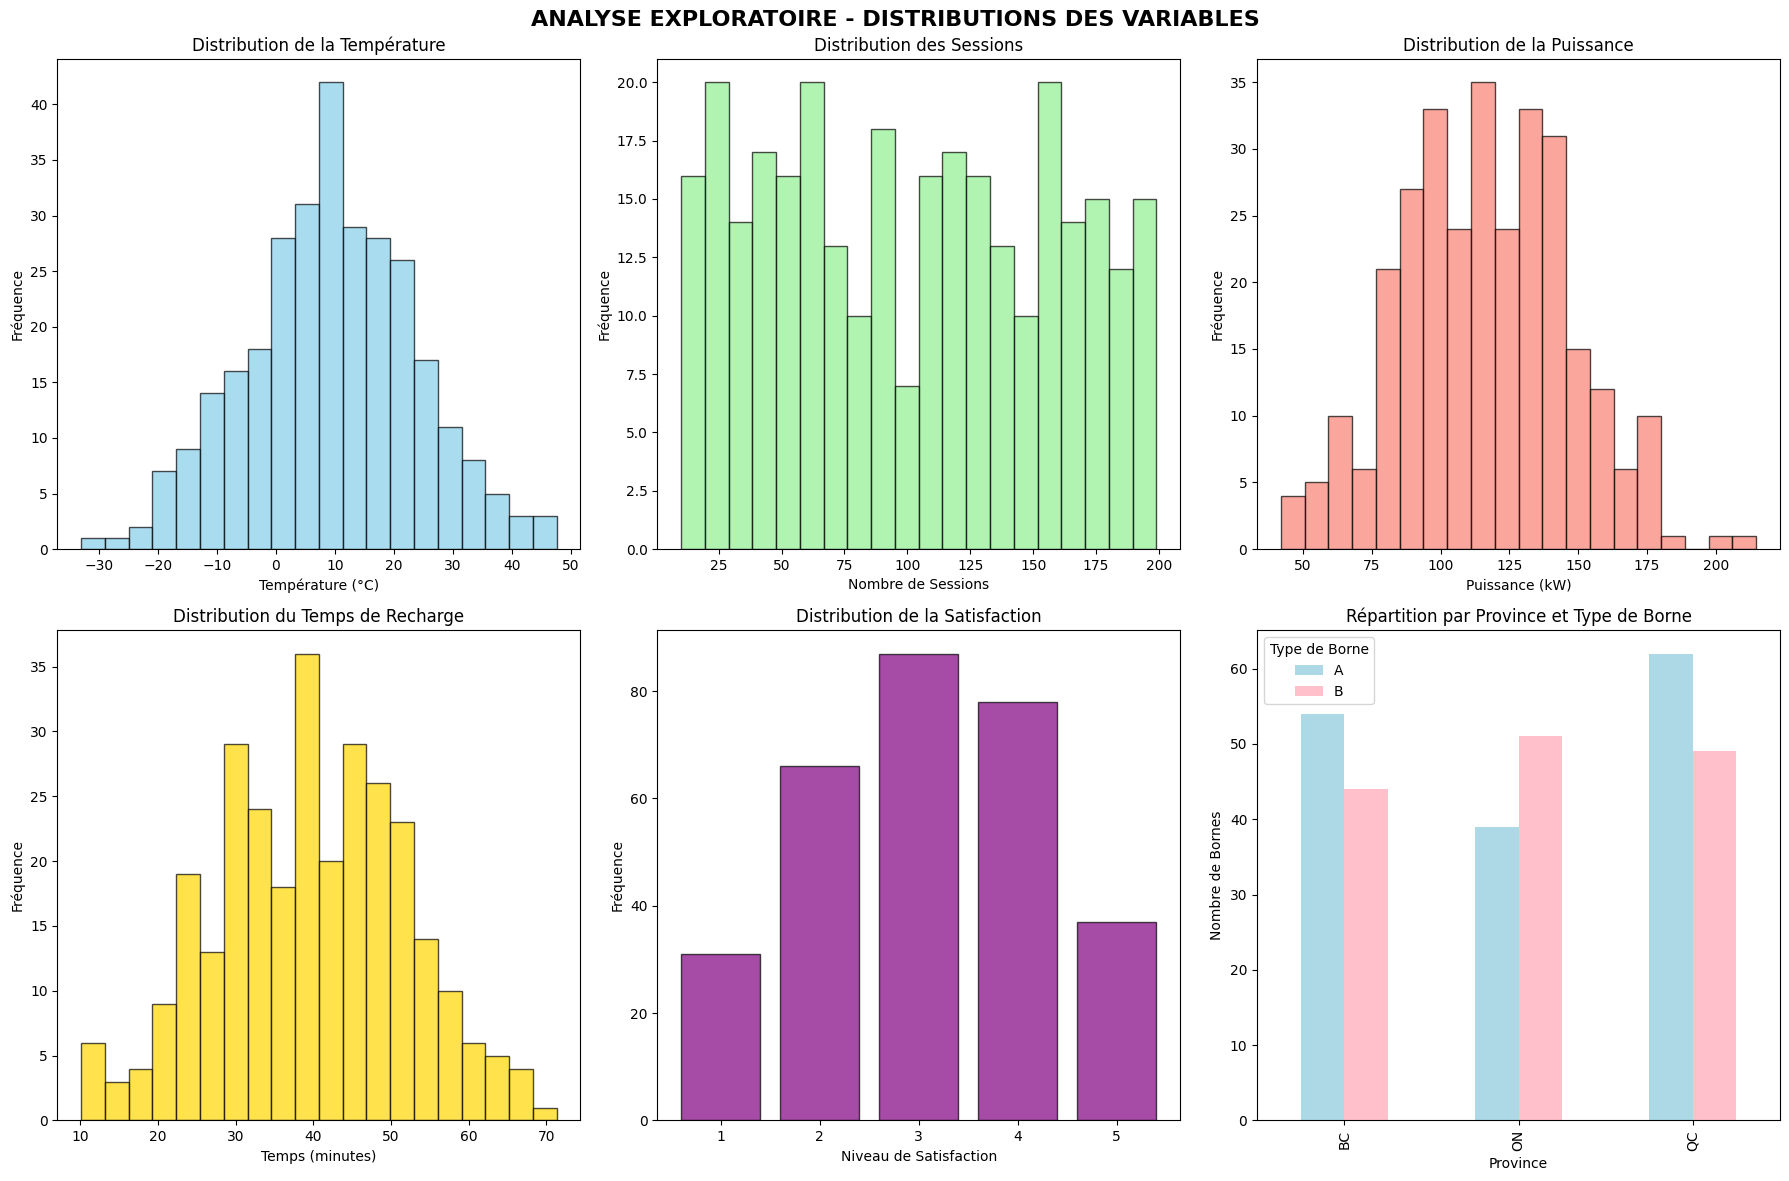


 ANALYSE PAR PROVINCE ET TYPE DE BORNE

 Statistiques par province:
         temperature        sessions        power_kw        recharge_time  \
                mean    std     mean    std     mean    std          mean   
province                                                                    
BC             16.97  12.92   105.09  52.09   114.67  29.85         39.35   
ON             11.23  10.87    97.32  57.14   121.98  30.35         38.70   
QC              1.09  13.66   102.14  57.56   112.18  30.28         40.59   

                satisfaction        
            std         mean   std  
province                            
BC        12.71         3.10  1.29  
ON        11.98         3.09  1.12  
QC        11.91         3.05  1.13  

Statistiques par type de borne:
           temperature        sessions        power_kw        recharge_time  \
                  mean    std     mean    std     mean    std          mean   
borne_type                                             

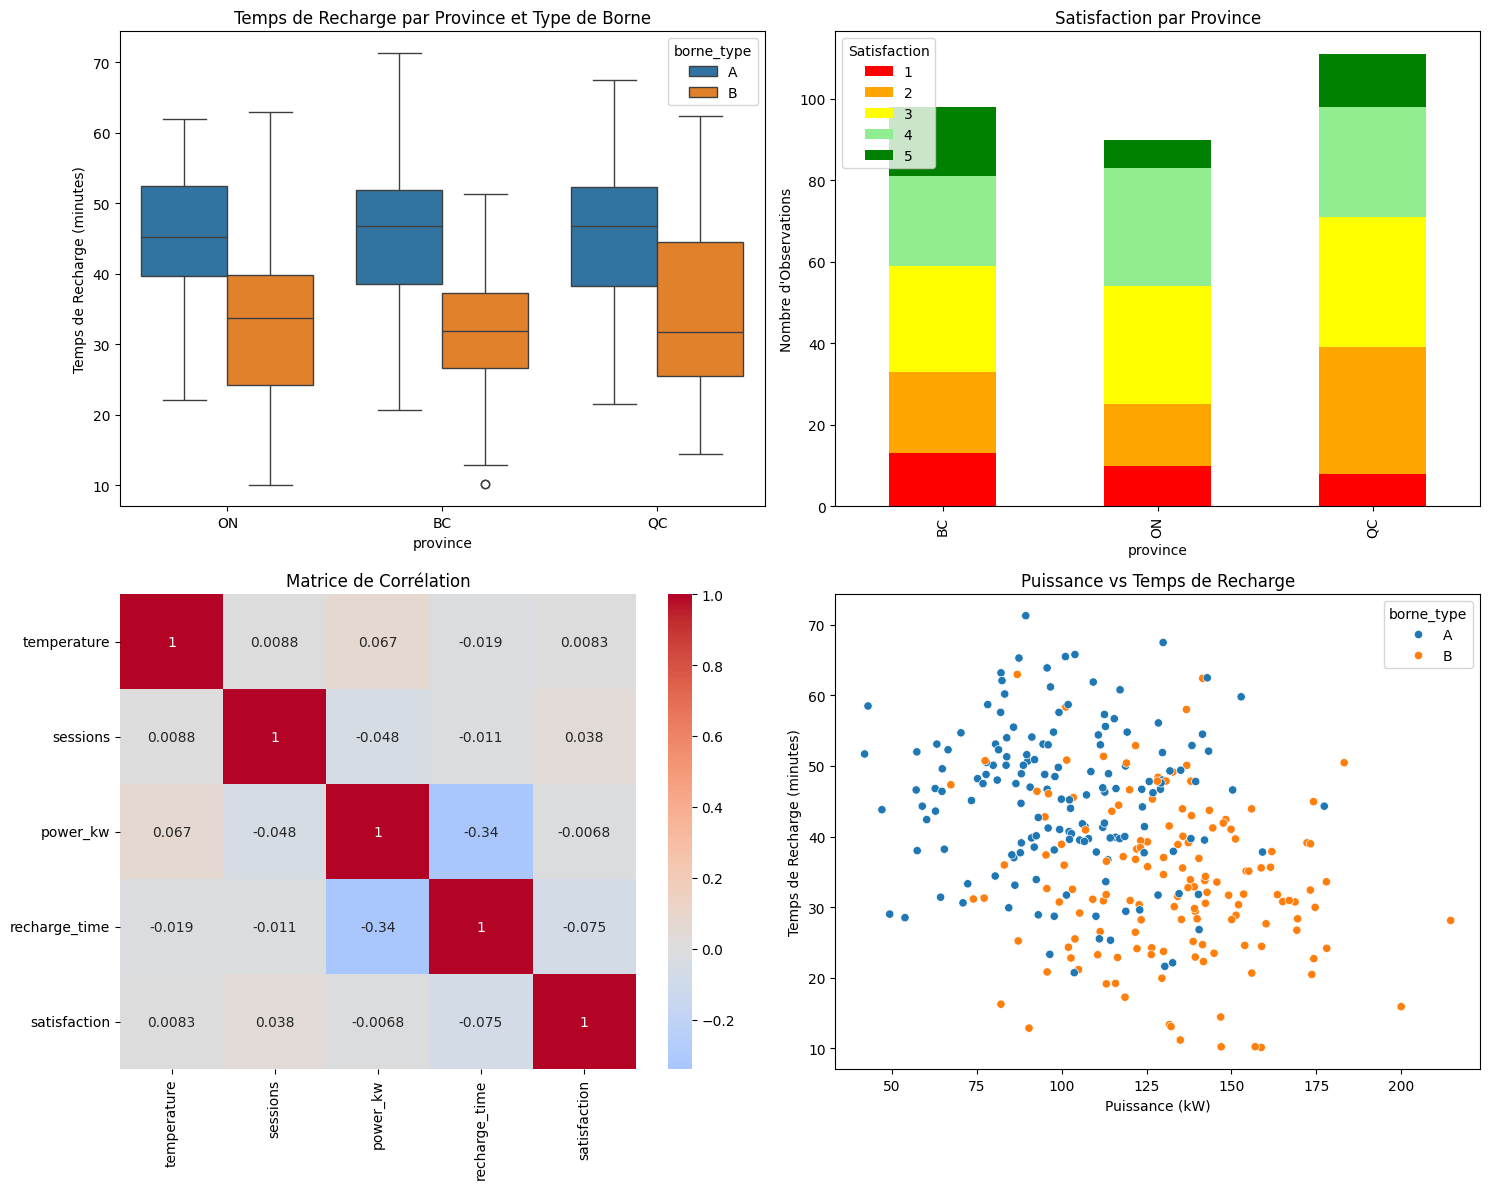

In [74]:

# ANALYSE EXPLORATOIRE COMPLÈTE


print("\n. ANALYSE EXPLORATOIRE COMPLÈTE")


# Configuration des graphiques
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ANALYSE EXPLORATOIRE - DISTRIBUTIONS DES VARIABLES', fontsize=16, fontweight='bold')

# Distribution de la température
axes[0,0].hist(df['temperature'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution de la Température')
axes[0,0].set_xlabel('Température (°C)')
axes[0,0].set_ylabel('Fréquence')

# Distribution des sessions
axes[0,1].hist(df['sessions'], bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Distribution des Sessions')
axes[0,1].set_xlabel('Nombre de Sessions')
axes[0,1].set_ylabel('Fréquence')

# Distribution de la puissance
axes[0,2].hist(df['power_kw'], bins=20, alpha=0.7, color='salmon', edgecolor='black')
axes[0,2].set_title('Distribution de la Puissance')
axes[0,2].set_xlabel('Puissance (kW)')
axes[0,2].set_ylabel('Fréquence')

# Distribution du temps de recharge
axes[1,0].hist(df['recharge_time'], bins=20, alpha=0.7, color='gold', edgecolor='black')
axes[1,0].set_title('Distribution du Temps de Recharge')
axes[1,0].set_xlabel('Temps (minutes)')
axes[1,0].set_ylabel('Fréquence')

# Distribution de la satisfaction
satisfaction_counts = df['satisfaction'].value_counts().sort_index()
axes[1,1].bar(satisfaction_counts.index, satisfaction_counts.values, 
              color='purple', alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribution de la Satisfaction')
axes[1,1].set_xlabel('Niveau de Satisfaction')
axes[1,1].set_ylabel('Fréquence')

# Répartition par province et type de borne
province_type = pd.crosstab(df['province'], df['borne_type'])
province_type.plot(kind='bar', ax=axes[1,2], color=['lightblue', 'pink'])
axes[1,2].set_title('Répartition par Province et Type de Borne')
axes[1,2].set_xlabel('Province')
axes[1,2].set_ylabel('Nombre de Bornes')
axes[1,2].legend(title='Type de Borne')

plt.tight_layout()
plt.show()
# Analyse par province et type de borne
print("\n ANALYSE PAR PROVINCE ET TYPE DE BORNE")


# Statistiques par province
print("\n Statistiques par province:")
province_stats = df.groupby('province').agg({
    'temperature': ['mean', 'std'],
    'sessions': ['mean', 'std'],
    'power_kw': ['mean', 'std'],
    'recharge_time': ['mean', 'std'],
    'satisfaction': ['mean', 'std']
}).round(2)
print(province_stats)

# Statistiques par type de borne
print("\nStatistiques par type de borne:")
borne_stats = df.groupby('borne_type').agg({
    'temperature': ['mean', 'std'],
    'sessions': ['mean', 'std'],
    'power_kw': ['mean', 'std'],
    'recharge_time': ['mean', 'std'],
    'satisfaction': ['mean', 'std']
}).round(2)
print(borne_stats)
# Visualisations avancées
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Temps de recharge par province et type de borne
sns.boxplot(data=df, x='province', y='recharge_time', hue='borne_type', ax=axes[0,0])
axes[0,0].set_title('Temps de Recharge par Province et Type de Borne')
axes[0,0].set_ylabel('Temps de Recharge (minutes)')

# Satisfaction par province
satisfaction_by_province = df.groupby(['province', 'satisfaction']).size().unstack()
satisfaction_by_province.plot(kind='bar', stacked=True, ax=axes[0,1], 
                             color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
axes[0,1].set_title('Satisfaction par Province')
axes[0,1].set_ylabel('Nombre d\'Observations')
axes[0,1].legend(title='Satisfaction')

# Corrélation entre variables numériques
correlation_matrix = df[['temperature', 'sessions', 'power_kw', 'recharge_time', 'satisfaction']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,0])
axes[1,0].set_title('Matrice de Corrélation')

# Puissance vs Temps de recharge
sns.scatterplot(data=df, x='power_kw', y='recharge_time', hue='borne_type', ax=axes[1,1])
axes[1,1].set_title('Puissance vs Temps de Recharge')
axes[1,1].set_xlabel('Puissance (kW)')
axes[1,1].set_ylabel('Temps de Recharge (minutes)')

plt.tight_layout()
plt.show()

Partie 1 – ANOVA : ANOVA à deux facteurs
la variable dependane est recharge_time = interaction province × borne_type.

# VÉRIFICATION DES HYPOTHÈSES DE L'ANOVA

1 independance des observation: chaque observation représente une session de recharge distincte ;

aucune mesure répétée n’a été effectuée sur le même individu.
L’hypothèse d’indépendance est donc raisonnablement satisfaite.


 TEST DE NORMALITÉ (Shapiro-Wilk) PAR GROUPE

 TABLEAU DES RÉSULTATS SHAPIRO-WILK :
Province Type_Borne  n  W (Shapiro)  p-value
      ON          A 39        0.966   0.2754
      ON          B 51        0.986   0.8143
      BC          A 54        0.987   0.8222
      BC          B 44        0.964   0.1800
      QC          A 62        0.983   0.5336
      QC          B 49        0.962   0.1122

 INTERPRÉTATION – NORMALITÉ :
 Tous les groupes respectent la normalité (p > 0.05).
 Certains groupes ont n > 50 → Shapiro devient trop sensible.
 Ajout automatique de QQ-plots pour confirmer visuellement la normalité.

 GÉNÉRATION DES QQ-PLOTS POUR CHAQUE GROUPE


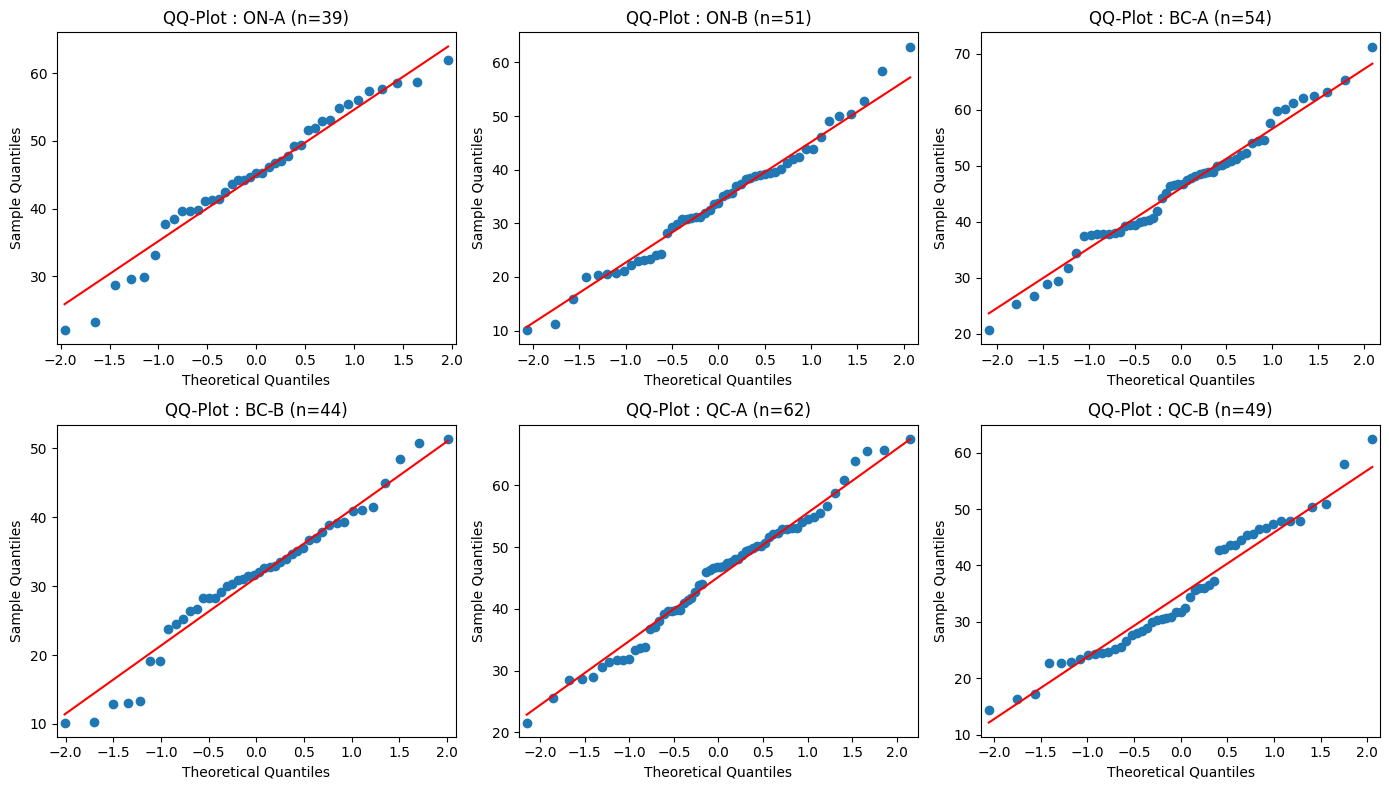

In [75]:

#  2 TEST DE NORMALITÉ (SHAPIRO-WILK) + TABLE + INTERPRÉTATION

print("\n TEST DE NORMALITÉ (Shapiro-Wilk) PAR GROUPE")


rows = []
need_qqplot = False

for province in df['province'].unique():
    for borne_type in df['borne_type'].unique():
        subset = df[(df['province'] == province) & 
                    (df['borne_type'] == borne_type)]['recharge_time']
        
        n = len(subset)
        if n >= 3:
            W, p = stats.shapiro(subset)
            rows.append([province, borne_type, n, round(W, 3), round(p, 4)])
            
            if n > 50:
                need_qqplot = True

# Créer tableau Shapiro
shapiro_table = pd.DataFrame(rows, 
                             columns=["Province", "Type_Borne", "n", "W (Shapiro)", "p-value"])

print("\n TABLEAU DES RÉSULTATS SHAPIRO-WILK :")
print(shapiro_table.to_string(index=False))

# Interprétation
print("\n INTERPRÉTATION – NORMALITÉ :")
if (shapiro_table["p-value"] < 0.05).any():
    print(" Certains groupes ne sont PAS normaux (p < 0.05).")
else:
    print(" Tous les groupes respectent la normalité (p > 0.05).")

if need_qqplot:
    print(" Certains groupes ont n > 50 → Shapiro devient trop sensible.")
    print(" Ajout automatique de QQ-plots pour confirmer visuellement la normalité.\n")
else:
    print("✓Tous les groupes ont n ≤ 50 → Shapiro est parfaitement approprié.\n")

# -PLOTS POUR TOUS LES GROUPES

print(" GÉNÉRATION DES QQ-PLOTS POUR CHAQUE GROUPE")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, row in enumerate(rows):
    province, borne_type, n, _, _ = row
    subset = df[(df['province'] == province) &
                (df['borne_type'] == borne_type)]['recharge_time']

    sm.qqplot(subset, line="s", ax=axes[i])
    axes[i].set_title(f"QQ-Plot : {province}-{borne_type} (n={n})")

plt.tight_layout()
plt.show()



In [76]:

# 3 TEST D’HOMOGÉNÉITÉ DES VARIANCES (LEvene)


print("\n TEST D'HOMOSCÉDASTICITÉ (Levene)")
groups = [df[(df['province']==p) & 
             (df['borne_type']==b)]['recharge_time'].dropna()
          for p in df['province'].unique()
          for b in df['borne_type'].unique()]

groups = [g for g in groups if len(g) > 2] 
stat_levene, p_levene = stats.levene(*groups)
print(f"Statistique de Levene = {stat_levene:.3f}, p-value = {p_levene:.3f}")

print("\n INTERPRÉTATION – HOMOSCÉDASTICITÉ :")
if p_levene > 0.05:
    print(" Variances homogènes (p > 0.05) → condition ANOVA respectée.")
else:
    print(" Variances hétérogènes (p < 0.05) → ANOVA classique NON valide.")





 TEST D'HOMOSCÉDASTICITÉ (Levene)
Statistique de Levene = 0.521, p-value = 0.761

 INTERPRÉTATION – HOMOSCÉDASTICITÉ :
 Variances homogènes (p > 0.05) → condition ANOVA respectée.


 4 Niveau de mesure de l'independance des variables

La variable dépendante (recharge_time) est une variable continue mesurée en minutes, ce qui satisfait l’hypothèse de niveau de mesure en intervalle.


#  Conclusion

L’ensemble des hypothèses de l’ANOVA sont remplies ou raisonnablement satisfaites, ce qui permet d’interpréter les résultats de l’ANOVA de manière valide.

In [77]:

#  ANOVA À DEUX FACTEURS AVEC INTERACTION

import statsmodels.formula.api as smf
print("\n ANOVA À DEUX FACTEURS AVEC INTERACTION")

import statsmodels.formula.api as ols
from statsmodels.stats.anova import anova_lm

model =smf.ols('recharge_time ~ C(province) * C(borne_type)', data=df).fit()
anova_results = anova_lm(model, typ=2)
print(anova_results)

# Interprétation ANOVA
print("\n INTERPRÉTATION DES EFFETS ANOVA :")
for factor, p in anova_results['PR(>F)'].items():
    if p < 0.05:
        print(f" {factor} : effet significatif (p = {p:.4f})")
    else:
        print(f" {factor} : effet non significatif (p = {p:.4f})")





 ANOVA À DEUX FACTEURS AVEC INTERACTION
                                 sum_sq     df          F        PR(>F)
C(province)                   70.290908    2.0   0.310298  7.334692e-01
C(borne_type)              10582.092391    1.0  93.428897  2.303242e-19
C(province):C(borne_type)    273.041921    2.0   1.205338  3.010717e-01
Residual                   33186.232246  293.0        NaN           NaN

 INTERPRÉTATION DES EFFETS ANOVA :
 C(province) : effet non significatif (p = 0.7335)
 C(borne_type) : effet significatif (p = 0.0000)
 C(province):C(borne_type) : effet non significatif (p = 0.3011)
 Residual : effet non significatif (p = nan)


le temps de chage ne depend pas de la province ou se situe la borne mais plutot de la borne meme 

Le test de Tukey n'a pas été réalisé pour les raisons suivantes :

 Le facteur 'province' n'est pas significatif (p > 0.05).
   → Lorsqu’un facteur à plusieurs niveaux n’est pas significatif,
     il est inutile de comparer les provinces entre elles.

 L'interaction 'province × type de borne' n'est pas significative (p > 0.05).
   → Sans interaction significative, il est méthodologiquement incorrect
     d'examiner des comparaisons post-hoc entre combinaisons de groupes.

 Le facteur 'type de borne' comporte seulement deux niveaux (A et B).
   → Avec seulement deux groupes, l’ANOVA fournit déjà la comparaison directe.
     Un test post-hoc serait redondant et inutile.

 Conclusion : AUCUN test Tukey HSD n’est requis dans ce modèle.
   L’ANOVA fournit déjà toutes les comparaisons nécessaires.

PARTIE 2: Processus stochastiques.

# markov

In [78]:
# Simuler 30 jours en prenant les 30 premières valeurs
ts = df["sessions"].head(30).reset_index(drop=True)

# Discrétisation en 3 états
ts_states = pd.qcut(ts, 3, labels=["faible", "moyen", "élevé"])

# Construire la matrice de transition
states = ["faible", "moyen", "élevé"]
transition_matrix = pd.DataFrame(
    0, index=states, columns=states, dtype=float
)

for (i, j) in zip(ts_states[:-1], ts_states[1:]):
    transition_matrix.loc[i, j] += 1

# Normaliser pour obtenir les probabilités
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

print("\nMatrice de transition :\n")
print(transition_matrix)

# Distribution stationnaire
eigvals, eigvecs = np.linalg.eig(transition_matrix.T)
# Sélectionner l'autovecteur associé à la valeur propre = 1
stationary = eigvecs[:, np.isclose(eigvals, 1)]
# Normaliser pour obtenir une distribution (somme = 1)
stationary = stationary[:,0]
stationary = stationary / stationary.sum()

print("\nDistribution stationnaire :\n")
print(pd.Series(stationary, index=states))

# Prévision à 10 étapes
P10 = np.linalg.matrix_power(transition_matrix.values, 10)
print("\nPrévision à 10 jours :\n")
print(pd.DataFrame(P10, index=states, columns=states))


Matrice de transition :

          faible     moyen     élevé
faible  0.222222  0.333333  0.444444
moyen   0.400000  0.300000  0.300000
élevé   0.300000  0.400000  0.300000

Distribution stationnaire :

faible    0.310345+0.000000j
moyen     0.344828+0.000000j
élevé     0.344828+0.000000j
dtype: complex128

Prévision à 10 jours :

          faible     moyen     élevé
faible  0.310345  0.344828  0.344828
moyen   0.310345  0.344828  0.344828
élevé   0.310345  0.344828  0.344828


# MODELE ARIMA

In [79]:
# =============================================================================
# 2. PRÉPARATION DE LA SÉRIE TEMPORELLE
# =============================================================================

print("\n" + "=" * 80)
print("2. PRÉPARATION DE LA SÉRIE TEMPORELLE")
print("=" * 80)

# Création d'un index temporel si absent
if 'date' not in df.columns:
    print("\nCréation d'un index temporel quotidien...")
    df['date'] = pd.date_range(start='2024-01-01', periods=len(df), freq='D')
    print("Index temporel créé")

df['date'] = pd.to_datetime(df['date'])
df_original = df.copy()
df = df.set_index('date')

print(f"\nPériode analysée : {df.index.min().date()} à {df.index.max().date()}")
print(f"Nombre de jours : {len(df)}")

print("\nStatistiques descriptives des sessions :")
print(df['sessions'].describe().round(2))


# =============================================================================
# 4. TEST DE STATIONNARITÉ (AUGMENTED DICKEY-FULLER)
# =============================================================================

print("\n" + "=" * 80)
print("4. TEST DE STATIONNARITÉ (ADF)")
print("=" * 80)

from statsmodels.tsa.stattools import adfuller

def test_adf(series, nom='Série'):
    """Test de stationnarité Augmented Dickey-Fuller"""
    series_clean = series.dropna()
    result = adfuller(series_clean, autolag='AIC')
    
    print(f"\nTest ADF pour : {nom}")
    print("-" * 60)
    print(f"   Statistique ADF    : {result[0]:.6f}")
    print(f"   P-value            : {result[1]:.6f}")
    print(f"   Lags utilisés      : {result[2]}")
    print(f"   Observations       : {result[3]}")
    
    print("\n   Valeurs critiques :")
    for key, value in result[4].items():
        print(f"      Seuil {key:>3s} : {value:.4f}")
    
    print("-" * 60)
    if result[1] < 0.05:
        print(f"Conclusion : Série stationnaire (p = {result[1]:.4f} < 0.05)")
        is_stationary = True
        d_value = 0
    else:
        print(f"Conclusion : Série non stationnaire (p = {result[1]:.4f} ≥ 0.05)")
        is_stationary = False
        d_value = 1
    
    return is_stationary, d_value, result


is_stat, d_param, adf_result = test_adf(df['sessions'], 'Sessions originales')

print(f"\nParamètre d suggéré pour ARIMA : d = {d_param}")



2. PRÉPARATION DE LA SÉRIE TEMPORELLE

Création d'un index temporel quotidien...
Index temporel créé

Période analysée : 2024-01-01 à 2024-10-25
Nombre de jours : 299

Statistiques descriptives des sessions :
count    299.00
mean     101.66
std       55.60
min       10.00
25%       51.00
50%      102.00
75%      152.50
max      199.00
Name: sessions, dtype: float64

4. TEST DE STATIONNARITÉ (ADF)

Test ADF pour : Sessions originales
------------------------------------------------------------
   Statistique ADF    : -10.999449
   P-value            : 0.000000
   Lags utilisés      : 3
   Observations       : 295

   Valeurs critiques :
      Seuil  1% : -3.4527
      Seuil  5% : -2.8714
      Seuil 10% : -2.5720
------------------------------------------------------------
Conclusion : Série stationnaire (p = 0.0000 < 0.05)

Paramètre d suggéré pour ARIMA : d = 0



5. DÉCOMPOSITION SAISONNIÈRE

📊 Période de décomposition: 7 jours (cycle hebdomadaire)


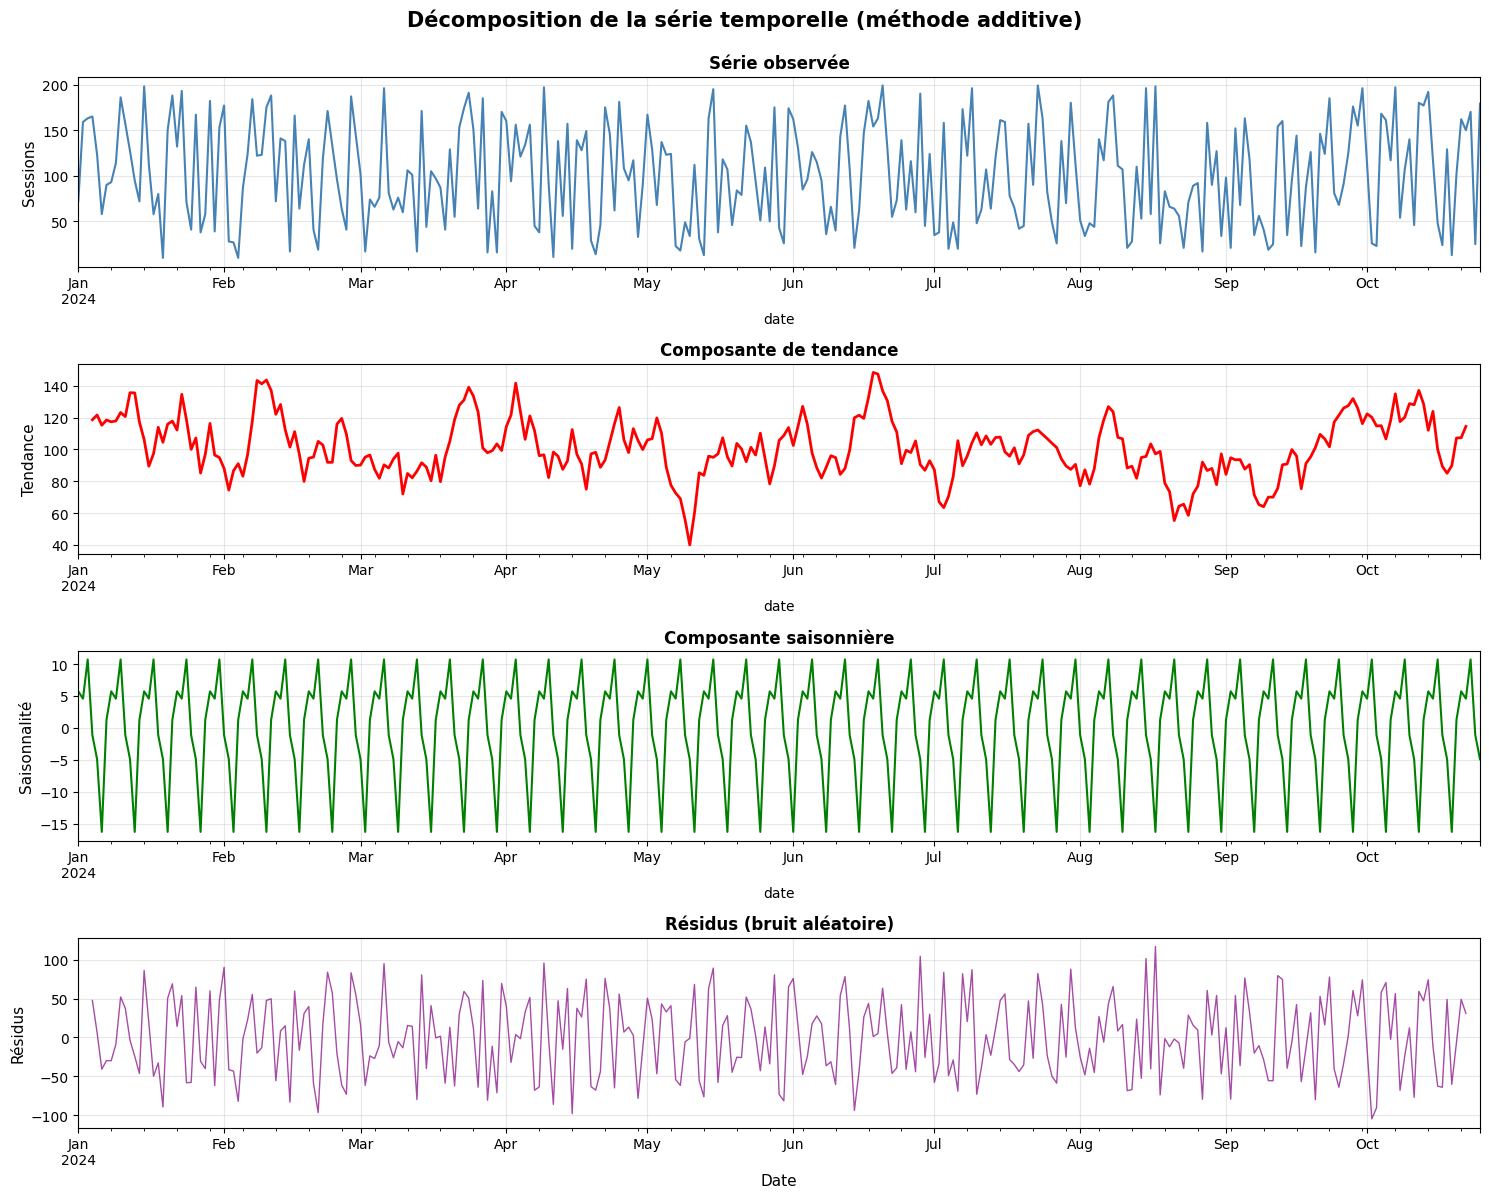

In [80]:
# =============================================================================
# 5. DÉCOMPOSITION SAISONNIÈRE
# =============================================================================

print("\n" + "=" * 80)
print("5. DÉCOMPOSITION SAISONNIÈRE")
print("=" * 80)

period = 7
print(f"\n📊 Période de décomposition: {period} jours (cycle hebdomadaire)")

decomposition = seasonal_decompose(df['sessions'].dropna(), model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomposition.observed.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Série observée', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sessions', fontsize=11)
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='red', linewidth=2)
axes[1].set_title('Composante de tendance', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tendance', fontsize=11)
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='green', linewidth=1.5)
axes[2].set_title('Composante saisonnière', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Saisonnalité', fontsize=11)
axes[2].grid(True, alpha=0.3)

decomposition.resid.plot(ax=axes[3], color='purple', linewidth=1, alpha=0.7)
axes[3].set_title('Résidus (bruit aléatoire)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Résidus', fontsize=11)
axes[3].set_xlabel('Date', fontsize=11)
axes[3].grid(True, alpha=0.3)

plt.suptitle('Décomposition de la série temporelle (méthode additive)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('partie2_fig2_decomposition.png', dpi=300, bbox_inches='tight')

plt.show()


6. ANALYSE D'AUTOCORRÉLATION (ACF/PACF)


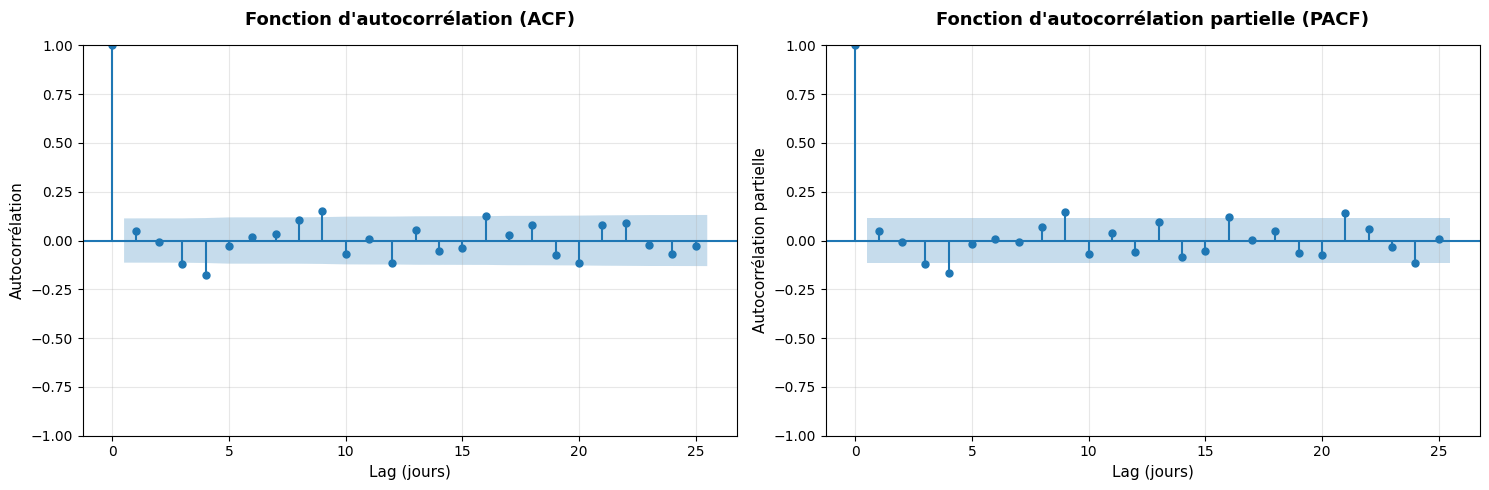

In [81]:
# =============================================================================
# 6. AUTOCORRÉLATION (ACF ET PACF) + EXTRACTION PARAMÈTRES ARIMA
# =============================================================================

print("\n" + "=" * 80)
print("6. ANALYSE D'AUTOCORRÉLATION (ACF/PACF)")
print("=" * 80)

# Calculer ACF et PACF
series_for_acf = df['sessions'].dropna()
acf_values = acf(series_for_acf, nlags=25, fft=False)
pacf_values = pacf(series_for_acf, nlags=25, method='ywm')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(series_for_acf, lags=25, ax=axes[0], alpha=0.05)
axes[0].set_title('Fonction d\'autocorrélation (ACF)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Lag (jours)', fontsize=11)
axes[0].set_ylabel('Autocorrélation', fontsize=11)
axes[0].grid(True, alpha=0.3)

plot_pacf(series_for_acf, lags=25, ax=axes[1], alpha=0.05)
axes[1].set_title('Fonction d\'autocorrélation partielle (PACF)', 
                  fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Lag (jours)', fontsize=11)
axes[1].set_ylabel('Autocorrélation partielle', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('partie2_fig3_acf_pacf.png', dpi=300, bbox_inches='tight')

plt.show()


In [82]:
# EXTRACTION AUTOMATIQUE DES PARAMÈTRES p et q
print("\n" + "=" * 80)
print(" EXTRACTION DES PARAMÈTRES ARIMA DEPUIS ACF/PACF")
print("=" * 80)

# Seuil de significativité (IC 95%)
n = len(series_for_acf)
conf_interval = 1.96 / np.sqrt(n)

# Déterminer q (ordre MA) depuis ACF
q_param = 0
for i in range(1, min(10, len(acf_values))):
    if abs(acf_values[i]) > conf_interval:
        q_param = i
    else:
        break

# Déterminer p (ordre AR) depuis PACF
p_param = 0
for i in range(1, min(10, len(pacf_values))):
    if abs(pacf_values[i]) > conf_interval:
        p_param = i
    else:
        break

print(f"\n Analyse ACF (pour paramètre q):")
print(f"   Seuil de significativité : ±{conf_interval:.4f}")
print(f"   Lags significatifs dans ACF : {[i for i in range(1, 10) if i < len(acf_values) and abs(acf_values[i]) > conf_interval]}")
print(f"   → Paramètre q suggéré : q = {q_param}")

print(f"\n Analyse PACF (pour paramètre p):")
print(f"   Lags significatifs dans PACF : {[i for i in range(1, 10) if i < len(pacf_values) and abs(pacf_values[i]) > conf_interval]}")
print(f"   → Paramètre p suggéré : p = {p_param}")

print(f"\n PARAMÈTRES ARIMA SUGGÉRÉS PAR ACF/PACF:")
print(f"{'─' * 60}")
print(f"   p (ordre AR)  : {p_param}")
print(f"   d (différenciation) : {d_param}")
print(f"   q (ordre MA)  : {q_param}")
print(f"\n   → Modèle suggéré : ARIMA({p_param}, {d_param}, {q_param})")



 EXTRACTION DES PARAMÈTRES ARIMA DEPUIS ACF/PACF

 Analyse ACF (pour paramètre q):
   Seuil de significativité : ±0.1133
   Lags significatifs dans ACF : [3, 4, 9]
   → Paramètre q suggéré : q = 0

 Analyse PACF (pour paramètre p):
   Lags significatifs dans PACF : [3, 4, 9]
   → Paramètre p suggéré : p = 0

 PARAMÈTRES ARIMA SUGGÉRÉS PAR ACF/PACF:
────────────────────────────────────────────────────────────
   p (ordre AR)  : 0
   d (différenciation) : 0
   q (ordre MA)  : 0

   → Modèle suggéré : ARIMA(0, 0, 0)


ARIMA(0,0,0) n’est PAS un modèle valide dans ce contexte.

Ce modèle équivaut à prédire la moyenne constante de la série.
C’est un modèle naïf, totalement inutilisable

p autoregression
d differenciation
q moyenne mobile
en prenant (0,0,0) on ne peut pas prendre les dernieres valeurs p, les dernieres erreur q de 0 differenciation pour predire 
on a utiliser une methode GRID SEARCH ARIMA AVEC d = 0 FIXÉ pour rechercher les meilleur metrique

In [83]:
# ===============================================================
#  GRID SEARCH ARIMA AVEC d = 0 FIXÉ
# ===============================================================



series = df["sessions"].dropna()

print("\n" + "=" * 80)
print("ARIMA GRID SEARCH (d = 0 fixé)")
print("=" * 80 + "\n")

# Définition des bornes de recherche
max_p = 4
max_q = 4
d = 0   # d fixé à 0 car série stationnaire

results = []
best_aic = np.inf
best_model = None
best_order = None

for p in range(max_p + 1):
    for q in range(max_q + 1):

        # Exclure le modèle trivial ARIMA(0,0,0)
        if p == 0 and q == 0:
            continue

        try:
            model = ARIMA(series, order=(p, d, q))
            fitted = model.fit()

            aic = fitted.aic
            bic = fitted.bic
            llf = fitted.llf

            results.append({
                "ARIMA": f"({p},{d},{q})",
                "AIC": aic,
                "BIC": bic,
                "LogLik": llf
            })

            print(f"ARIMA({p},{d},{q}) testé : AIC = {aic:.2f}")

            if aic < best_aic:
                best_aic = aic
                best_model = fitted
                best_order = (p, d, q)

        except Exception:
            print(f"ARIMA({p},{d},{q}) rejeté (non convergent)")
            continue


# ===============================================================
#  AFFICHAGE DU MEILLEUR MODÈLE
# ===============================================================

print("\n" + "=" * 80)
print("MEILLEUR MODÈLE SÉLECTIONNÉ")
print("=" * 80 + "\n")

print(f"Meilleur modèle (AIC minimal) : ARIMA{best_order}")
print(f"AIC : {best_aic:.2f}\n")

# Tableau ordonné des modèles testés
results_df = pd.DataFrame(results).sort_values("AIC")
print("Classement des modèles selon l'AIC :\n")
print(results_df.to_string(index=False))


# ===============================================================
#  RÉSUMÉ COMPLET DU MEILLEUR MODÈLE
# ===============================================================

print("\nRésumé du modèle sélectionné :\n")
print(best_model.summary())


# ===============================================================
#  DIAGNOSTIC DES RÉSIDUS
# ===============================================================

res = best_model.resid

print("\n" + "=" * 80)
print("DIAGNOSTIC DES RÉSIDUS")
print("=" * 80 + "\n")

print(f"Moyenne des résidus : {res.mean():.4f}")
print(f"Écart-type des résidus : {res.std():.4f}")
print(f"Min / Max des résidus : {res.min():.2f} / {res.max():.2f}")

# Test de Ljung-Box pour vérifier l'absence d'autocorrélation
lb = acorr_ljungbox(res, lags=10, return_df=True)

print("\nTest de Ljung-Box (autocorrélation des résidus) :\n")
print(lb)

if lb["lb_pvalue"].min() > 0.05:
    print("\nConclusion : les résidus ne sont pas autocorrélés (p > 0.05). Le modèle est statistiquement valide.")
else:
    print("\nConclusion : autocorrélation détectée dans les résidus (p < 0.05). Le modèle peut être amélioré.")



ARIMA GRID SEARCH (d = 0 fixé)

ARIMA(0,0,1) testé : AIC = 3255.71
ARIMA(0,0,2) testé : AIC = 3257.70
ARIMA(0,0,3) testé : AIC = 3256.21
ARIMA(0,0,4) testé : AIC = 3250.20
ARIMA(1,0,0) testé : AIC = 3255.71
ARIMA(1,0,1) testé : AIC = 3257.70
ARIMA(1,0,2) testé : AIC = 3256.60
ARIMA(1,0,3) testé : AIC = 3254.44
ARIMA(1,0,4) testé : AIC = 3251.93
ARIMA(2,0,0) testé : AIC = 3257.69
ARIMA(2,0,1) testé : AIC = 3255.67
ARIMA(2,0,2) testé : AIC = 3247.69
ARIMA(2,0,3) testé : AIC = 3249.19
ARIMA(2,0,4) testé : AIC = 3250.32
ARIMA(3,0,0) testé : AIC = 3255.36
ARIMA(3,0,1) testé : AIC = 3252.29
ARIMA(3,0,2) testé : AIC = 3249.11
ARIMA(3,0,3) testé : AIC = 3251.03
ARIMA(3,0,4) testé : AIC = 3249.71
ARIMA(4,0,0) testé : AIC = 3248.87
ARIMA(4,0,1) testé : AIC = 3250.76
ARIMA(4,0,2) testé : AIC = 3252.74
ARIMA(4,0,3) testé : AIC = 3249.32
ARIMA(4,0,4) testé : AIC = 3250.74

MEILLEUR MODÈLE SÉLECTIONNÉ

Meilleur modèle (AIC minimal) : ARIMA(2, 0, 2)
AIC : 3247.69

Classement des modèles selon l'AIC 


8. PREVISIONS A 10 JOURS

Prévisions à 10 jours avec le modèle ARIMA(2, 0, 2):
---------------------------------------------------------------------------
Jour   Date            Prévision    IC 95% Inf    IC 95% Sup
---------------------------------------------------------------------------
1      2024-10-26        82.51        -23.59        188.61
2      2024-10-27        84.90        -21.23        191.03
3      2024-10-28        94.34        -11.99        200.67
4      2024-10-29       105.57         -1.36        212.49
5      2024-10-30       113.31          5.88        220.74
6      2024-10-31       114.64          7.09        222.19
7      2024-11-01       109.94          2.38        217.50
8      2024-11-02       102.20         -5.58        209.98
9      2024-11-03        95.33        -12.74        203.40
10     2024-11-04        92.26        -15.96        200.47

Statistiques des prévisions :
   Moyenne prévue       : 99.50 sessions/jour
   Tendance             : Hausse
   Vari

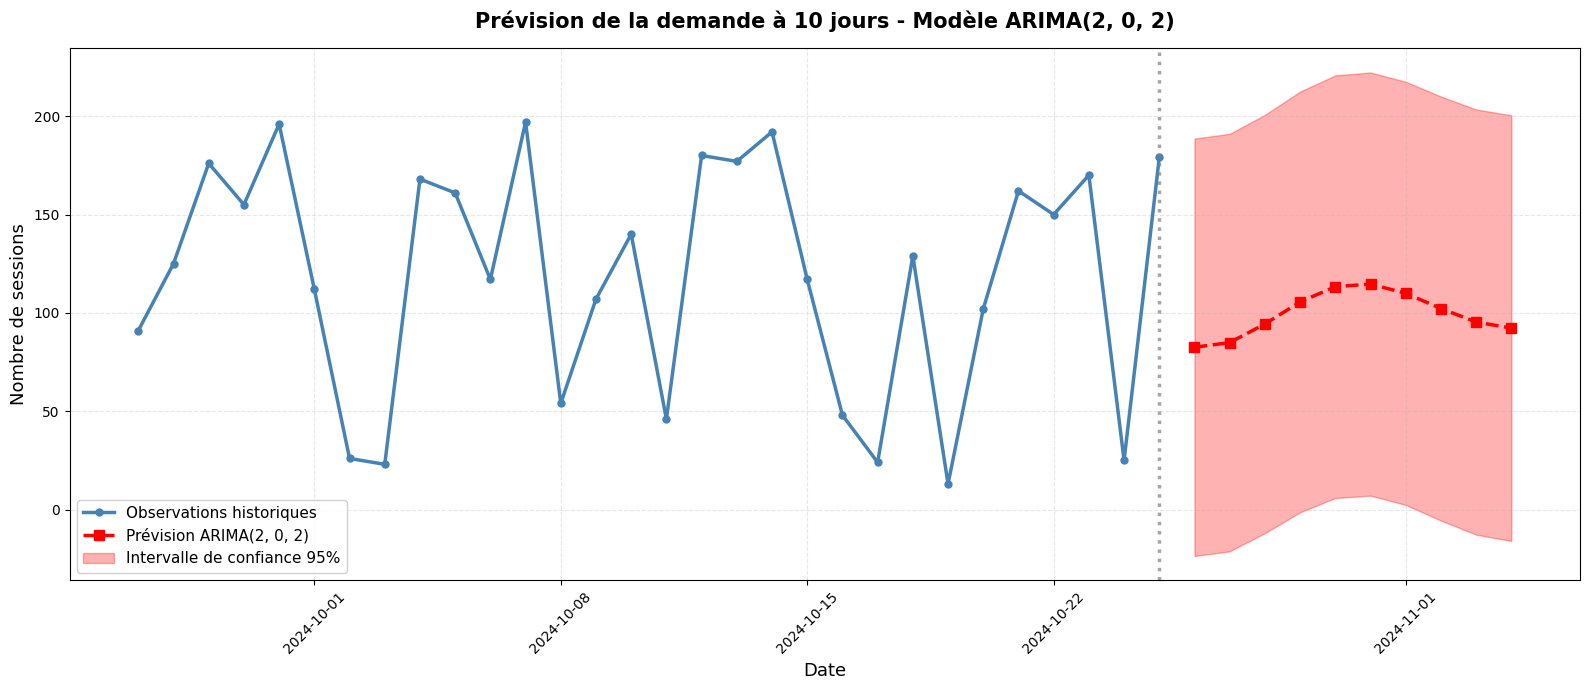

In [84]:
# =============================================================================
# 8. PRÉVISIONS ARIMA À 10 JOURS
# =============================================================================

print("\n" + "=" * 80)
print("8. PREVISIONS A 10 JOURS")
print("=" * 80)

forecast_steps = 10
forecast = best_model.forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), 
                                periods=forecast_steps, freq='D')

# Intervalle de confiance 95%
forecast_result = best_model.get_forecast(steps=forecast_steps)
forecast_ci = forecast_result.conf_int()

print(f"\nPrévisions à {forecast_steps} jours avec le modèle ARIMA{best_order}:")
print("-" * 75)
print(f"{'Jour':<6} {'Date':<12} {'Prévision':>12} {'IC 95% Inf':>13} {'IC 95% Sup':>13}")
print("-" * 75)

for i, date in enumerate(forecast_index, 1):
    pred = forecast.iloc[i-1] if hasattr(forecast, 'iloc') else forecast[i-1]
    lower = forecast_ci.iloc[i-1, 0]
    upper = forecast_ci.iloc[i-1, 1]
    print(f"{i:<6} {date.date()} {pred:>12.2f} {lower:>13.2f} {upper:>13.2f}")

# Statistiques descriptives des prévisions
print("\nStatistiques des prévisions :")
print(f"   Moyenne prévue       : {forecast.mean():.2f} sessions/jour")
print(f"   Tendance             : {'Hausse' if forecast.iloc[-1] > forecast.iloc[0] else 'Baisse'}")
print(f"   Variation J1 à J10   : {forecast.iloc[-1] - forecast.iloc[0]:+.2f} sessions")
print(f"   Variation en %       : {((forecast.iloc[-1] / forecast.iloc[0]) - 1) * 100:+.2f}%")

# Visualisation des prévisions
fig, ax = plt.subplots(figsize=(16, 7))

# Observations historiques (30 derniers jours)
ax.plot(df.index[-30:], df['sessions'].iloc[-30:], 
        linewidth=2.5, color='steelblue', label='Observations historiques',
        marker='o', markersize=5)

# Prévisions
ax.plot(forecast_index, forecast, 
        linewidth=2.5, color='red', linestyle='--',
        label=f'Prévision ARIMA{best_order}',
        marker='s', markersize=7)

# Intervalle de confiance
ax.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                alpha=0.3, color='red', label='Intervalle de confiance 95%')

# Ligne verticale de séparation (fin des données)
ax.axvline(x=df.index[-1], color='gray', linestyle=':', linewidth=2.5, alpha=0.7)

ax.set_title(f'Prévision de la demande à {forecast_steps} jours - Modèle ARIMA{best_order}',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Nombre de sessions', fontsize=13)
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('partie2_fig4_arima_forecast.png', dpi=300, bbox_inches='tight')
plt.show()


In [85]:
# =============================================================================
# 9. PRÉVISIONS PAR PROVINCE ET PAR TYPE DE BORNE AVEC LES PARAMÈTRES GLOBALS
# =============================================================================

print("\n" + "=" * 80)
print("9. PRÉVISIONS PAR PROVINCE / BORNE AVEC ARIMA GLOBAL")
print("=" * 80)

# Récupérer les paramètres globaux trouvés avant
p_global, d_global, q_global = best_order
print(f"\n Paramètres ARIMA globaux utilisés : ARIMA({p_global},{d_global},{q_global})")

df_grouped = df.reset_index()
forecasts_dict = {}

# Fonction générique : appliquer ARIMA global à une sous-série
def apply_global_arima(series, p, d, q):
    try:
        model = ARIMA(series, order=(p, d, q))
        fitted = model.fit()
        forecast = fitted.forecast(steps=10)
        return fitted, forecast
    except Exception as e:
        return None, None


# =====================================================================
# 9.1 PRÉVISIONS PAR PROVINCE
# =====================================================================
print("\n 9.1 PRÉVISIONS PAR PROVINCE")
print("=" * 70)

for province in df_grouped["province"].unique():
    df_prov = df_grouped[df_grouped["province"] == province].copy()
    df_prov = df_prov.set_index("date")
    series_prov = df_prov["sessions"].dropna()

    if len(series_prov) < 15:
        print(f"\n Province {province} : données insuffisantes ({len(series_prov)} obs)")
        continue

    model, forecast = apply_global_arima(series_prov, p_global, d_global, q_global)

    print(f"\n Province : {province}")
    print(f"   Modèle utilisé     : ARIMA({p_global},{d_global},{q_global})")
    print(f"   Sessions actuelles : {series_prov.iloc[-5:].mean():.2f}")
    print(f"   Prévision moyenne  : {forecast.mean():.2f}")
    print(f"   Croissance prévue  : {((forecast.mean() / series_prov.iloc[-1]) - 1) * 100:+.2f}%")

    forecasts_dict[f"province_{province}"] = {
        "model": model,
        "order": best_order,
        "forecast": forecast
    }


# =====================================================================
# 9.2 PRÉVISIONS PAR TYPE DE BORNE
# =====================================================================
print("\n 9.2 PRÉVISIONS PAR TYPE DE BORNE")
print("=" * 70)

for borne in df_grouped["borne_type"].unique():
    df_borne = df_grouped[df_grouped["borne_type"] == borne].copy()
    df_borne = df_borne.set_index("date")
    series_borne = df_borne["sessions"].dropna()

    if len(series_borne) < 15:
        print(f"\n Borne {borne} : données insuffisantes")
        continue

    model, forecast = apply_global_arima(series_borne, p_global, d_global, q_global)

    print(f"\n Type de borne : {borne}")
    print(f"   Modèle utilisé     : ARIMA({p_global},{d_global},{q_global})")
    print(f"   Sessions actuelles : {series_borne.iloc[-5:].mean():.2f}")
    print(f"   Prévision moyenne  : {forecast.mean():.2f}")
    print(f"   Croissance prévue  : {((forecast.mean() / series_borne.iloc[-1]) - 1) * 100:+.2f}%")

    forecasts_dict[f"borne_{borne}"] = {
        "model": model,
        "order": best_order,
        "forecast": forecast
    }


# =====================================================================
# 9.3 PRÉVISIONS CROISÉES : PROVINCE × TYPE DE BORNE
# =====================================================================
print("\n 9.3 PRÉVISIONS CROISÉES PROVINCE × TYPE DE BORNE")
print("=" * 70)

for province in df_grouped["province"].unique():
    for borne in df_grouped["borne_type"].unique():

        df_cross = df_grouped[(df_grouped["province"] == province) &
                              (df_grouped["borne_type"] == borne)].copy()
        df_cross = df_cross.set_index("date")
        series_cross = df_cross["sessions"].dropna()

        if len(series_cross) < 10:
            print(f"\n {province}-{borne} : données insuffisantes")
            continue

        model, forecast = apply_global_arima(series_cross, p_global, d_global, q_global)

        print(f"\n {province} — Borne {borne}")
        print(f"   Modèle utilisé     : ARIMA({p_global},{d_global},{q_global})")
        print(f"   Sessions actuelles : {series_cross.iloc[-5:].mean():.2f}")
        print(f"   Prévision moyenne  : {forecast.mean():.2f}")
        print(f"   Croissance prévue  : {((forecast.mean() / series_cross.iloc[-1]) - 1) * 100:+.2f}%")

        forecasts_dict[f"{province}_{borne}"] = {
            "model": model,
            "order": best_order,
            "forecast": forecast
        }



9. PRÉVISIONS PAR PROVINCE / BORNE AVEC ARIMA GLOBAL

 Paramètres ARIMA globaux utilisés : ARIMA(2,0,2)

 9.1 PRÉVISIONS PAR PROVINCE

 Province : ON
   Modèle utilisé     : ARIMA(2,0,2)
   Sessions actuelles : 98.80
   Prévision moyenne  : 93.57
   Croissance prévue  : +274.26%

 Province : BC
   Modèle utilisé     : ARIMA(2,0,2)
   Sessions actuelles : 145.00
   Prévision moyenne  : 110.04
   Croissance prévue  : -26.64%

 Province : QC
   Modèle utilisé     : ARIMA(2,0,2)
   Sessions actuelles : 104.60
   Prévision moyenne  : 105.21
   Croissance prévue  : -41.22%

 9.2 PRÉVISIONS PAR TYPE DE BORNE

 Type de borne : A
   Modèle utilisé     : ARIMA(2,0,2)
   Sessions actuelles : 74.00
   Prévision moyenne  : 98.09
   Croissance prévue  : -45.20%

 Type de borne : B
   Modèle utilisé     : ARIMA(2,0,2)
   Sessions actuelles : 155.20
   Prévision moyenne  : 117.71
   Croissance prévue  : -30.76%

 9.3 PRÉVISIONS CROISÉES PROVINCE × TYPE DE BORNE

 ON — Borne A
   Modèle utilisé     : 

Partie 3 – Approche bayésienne

P(D|A)   = 0.2769 → 27.7%
P(D|A,A) = 0.6968 → 69.7%


,P(D) a priori,P(D|A),"P(D|A,A)"
0,0.010,0.057,0.267
1,0.020,0.109,0.424
2,0.030,0.157,0.527
3,0.040,0.200,0.600
4,0.050,0.240,0.655
5,0.060,0.277,0.697
6,0.070,0.311,0.730
7,0.080,0.343,0.758
8,0.090,0.372,0.781
9,0.100,0.400,0.800


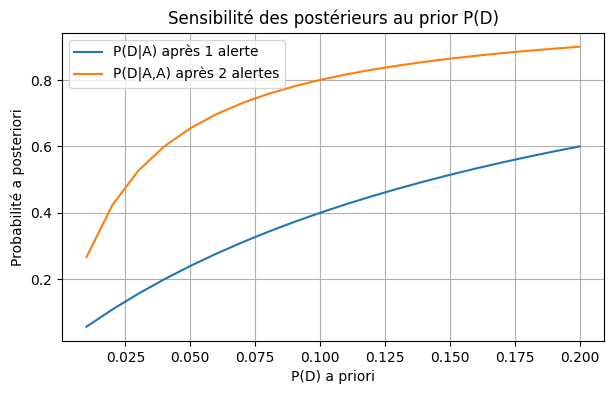

In [86]:


# Paramètres de base
pD = 0.06
pA_D = 0.90
pA_notD = 0.15

def posterior_n(pD, pA_D, pA_notD, n=1):
    num = (pA_D**n) * pD
    den = num + (pA_notD**n) * (1 - pD)
    return num / den

# 1 et 2 alertes (exemples)
p1 = posterior_n(pD, pA_D, pA_notD, n=1)
p2 = posterior_n(pD, pA_D, pA_notD, n=2)
print(f"P(D|A)   = {p1:.4f} → {p1*100:.1f}%")
print(f"P(D|A,A) = {p2:.4f} → {p2*100:.1f}%")

# Sensibilité aux priors
priors = np.linspace(0.01, 0.20, 20)
rows = []
for prior in priors:
    rows.append([prior, posterior_n(prior, pA_D, pA_notD, n=1), posterior_n(prior, pA_D, pA_notD, n=2)])
sens_df = pd.DataFrame(rows, columns=["P(D) a priori", "P(D|A)", "P(D|A,A)"])
display(sens_df.style.format("{:.3f}"))

# Graphique
plt.figure(figsize=(7,4))
plt.plot(priors, sens_df["P(D|A)"], label="P(D|A) après 1 alerte")
plt.plot(priors, sens_df["P(D|A,A)"], label="P(D|A,A) après 2 alertes")
plt.xlabel("P(D) a priori")
plt.ylabel("Probabilité a posteriori")
plt.title("Sensibilité des postérieurs au prior P(D)")
plt.legend()
plt.grid(True)
plt.show()


# partie 4

In [87]:

# Carte centrée sur le Canada
map_canada = folium.Map(location=[57, -96], zoom_start=4)

# Choroplèthe satisfaction par province
folium.Choropleth(
    geo_data="canada.geojson",
    data=df,
    columns=("province", "satisfaction"),
    key_on="feature.properties.name",
    fill_color="YlGnBu",
    line_color="black",
    legend_name="Satisfaction moyenne"
).add_to(map_canada)

map_canada.save("ma_carte.html")



In [88]:


# Conversion des codes provinciaux en noms compatibles avec le GeoJSON
df_geo = df.copy()
df_geo["province"] = df_geo["province"].replace({
    "ON": "Ontario",
    "QC": "Quebec",
    "BC": "British Columbia"
})

# Agréger satisfaction par province
df_grouped = df_geo.groupby("province")["satisfaction"].mean().reset_index()

# Carte centrée
map_canada = folium.Map(location=[57, -96], zoom_start=4)

# Choroplèthe (carte colorée)
folium.Choropleth(
    geo_data="canada.geojson",
    data=df_grouped,
    columns=("province", "satisfaction"),
    key_on="feature.properties.name",
    fill_color="YlGnBu",
    fill_opacity=0.8,
    line_opacity=1,
    legend_name="Satisfaction moyenne"
).add_to(map_canada)

# Sauvegarder la carte (obligatoire dans VS Code)
map_canada.save("carte_satisfaction.html")



 GRAPHIQUE D'INTERACTION

 Données pour le graphique d'interaction:
  province borne_type       mean        std  count        ci
0       BC          A  45.955556  10.745981     54  2.866192
1       BC          B  31.248235  10.001127     44  2.955144
2       ON          A  44.920513   9.824196     39  3.083336
3       ON          B  33.935411  11.353567     51  3.116042
4       QC          A  45.172581  10.468519     62  2.605826
5       QC          B  34.801248  11.149840     49  3.121955


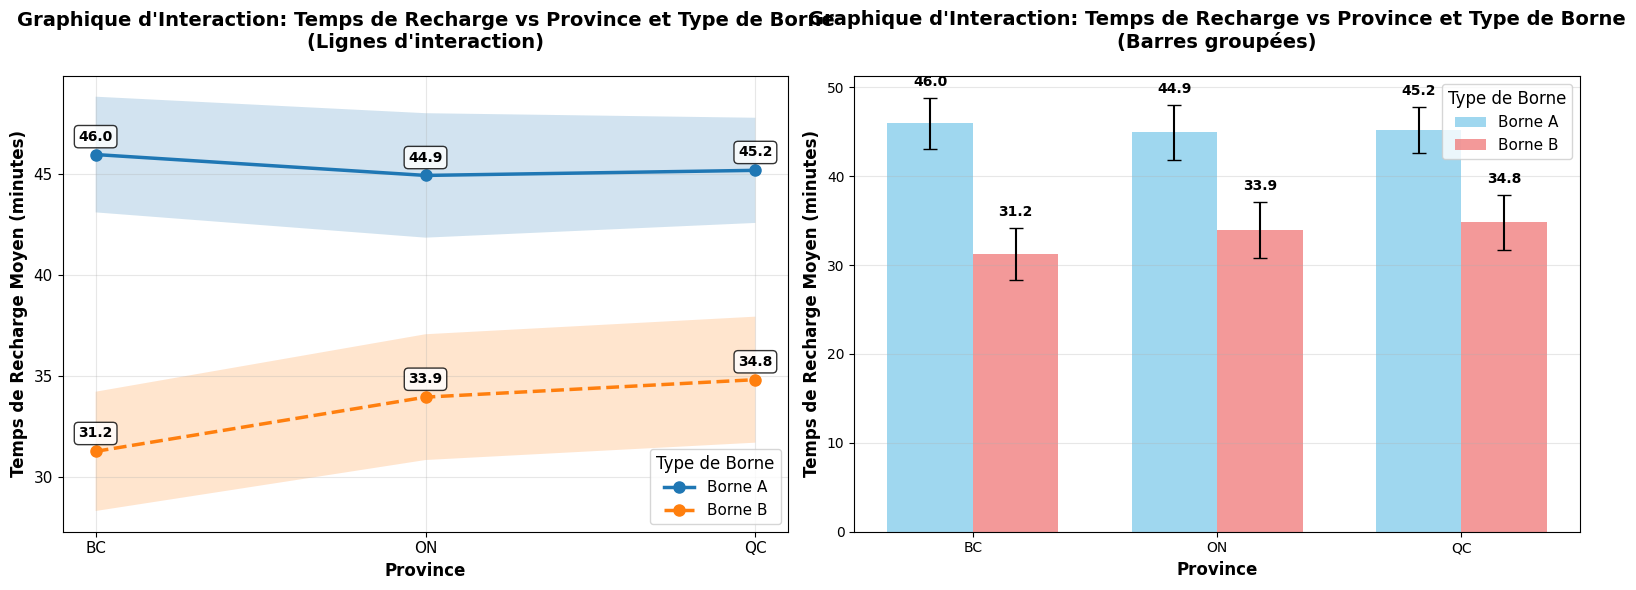


 ANALYSE DÉTAILLÉE DE L'INTERACTION:
Province BC:
  • Borne A: 46.0 min
  • Borne B: 31.2 min
  • Différence (B-A): -14.7 min
  → Les bornes B rechargent beaucoup plus rapidement que les bornes A.

Province ON:
  • Borne A: 44.9 min
  • Borne B: 33.9 min
  • Différence (B-A): -11.0 min
  → Les bornes B rechargent beaucoup plus rapidement que les bornes A.

Province QC:
  • Borne A: 45.2 min
  • Borne B: 34.8 min
  • Différence (B-A): -10.4 min
  → Les bornes B rechargent beaucoup plus rapidement que les bornes A.



In [89]:

# GRAPHIQUE D'INTERACTION - Temps de Recharge vs Province et Type de Borne


print("\n GRAPHIQUE D'INTERACTION")
print("=" * 35)

# Calcul des moyennes pour le graphique d'interaction
interaction_data = df.groupby(['province', 'borne_type'])['recharge_time'].agg(['mean', 'std', 'count']).reset_index()
interaction_data['ci'] = 1.96 * interaction_data['std'] / np.sqrt(interaction_data['count'])

print("\n Données pour le graphique d'interaction:")
print(interaction_data)

# Création du graphique d'interaction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Lignes d'interaction
for borne_type in interaction_data['borne_type'].unique():
    subset = interaction_data[interaction_data['borne_type'] == borne_type]
    ax1.plot(subset['province'], subset['mean'], 
             marker='o', linewidth=2.5, markersize=8, 
             label=f'Borne {borne_type}',
             linestyle='-' if borne_type == 'A' else '--')
    
    # Ajout des intervalles de confiance
    ax1.fill_between(subset['province'], 
                    subset['mean'] - subset['ci'], 
                    subset['mean'] + subset['ci'], 
                    alpha=0.2)

ax1.set_xlabel('Province', fontsize=12, fontweight='bold')
ax1.set_ylabel('Temps de Recharge Moyen (minutes)', fontsize=12, fontweight='bold')
ax1.set_title('Graphique d\'Interaction: Temps de Recharge vs Province et Type de Borne\n(Lignes d\'interaction)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(title='Type de Borne', title_fontsize=12, fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=11)

# Ajout des valeurs sur les points
for i, row in interaction_data.iterrows():
    ax1.annotate(f'{row["mean"]:.1f}', 
                (row['province'], row['mean']),
                textcoords="offset points",
                xytext=(0,10), 
                ha='center', 
                fontsize=10, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Graphique 2: Barres groupées avec erreurs
x_pos = np.arange(len(interaction_data['province'].unique()))
width = 0.35

for i, borne_type in enumerate(interaction_data['borne_type'].unique()):
    subset = interaction_data[interaction_data['borne_type'] == borne_type]
    means = subset['mean'].values
    errors = subset['ci'].values
    
    ax2.bar(x_pos + i*width, means, width, 
            label=f'Borne {borne_type}',
            yerr=errors, 
            capsize=5,
            alpha=0.8,
            color='skyblue' if borne_type == 'A' else 'lightcoral')
    
    # Ajout des valeurs sur les barres
    for j, (mean, error) in enumerate(zip(means, errors)):
        ax2.text(x_pos[j] + i*width, mean + error + 1, 
                f'{mean:.1f}', 
                ha='center', 
                va='bottom',
                fontweight='bold',
                fontsize=10)

ax2.set_xlabel('Province', fontsize=12, fontweight='bold')
ax2.set_ylabel('Temps de Recharge Moyen (minutes)', fontsize=12, fontweight='bold')
ax2.set_title('Graphique d\'Interaction: Temps de Recharge vs Province et Type de Borne\n(Barres groupées)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xticks(x_pos + width/2)
ax2.set_xticklabels(interaction_data['province'].unique())
ax2.legend(title='Type de Borne', title_fontsize=12, fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Analyse détaillée de l'interaction
print("\n ANALYSE DÉTAILLÉE DE L'INTERACTION:")


# Calcul des différences entre types de borne par province
for province in interaction_data['province'].unique():
    subset = interaction_data[interaction_data['province'] == province]
    if len(subset) == 2:  # Les deux types de borne présents
        mean_a = subset[subset['borne_type'] == 'A']['mean'].values[0]
        mean_b = subset[subset['borne_type'] == 'B']['mean'].values[0]
        difference = mean_b - mean_a
        print(f"Province {province}:")
        print(f"  • Borne A: {mean_a:.1f} min")
        print(f"  • Borne B: {mean_b:.1f} min")
        print(f"  • Différence (B-A): {difference:+.1f} min")
        
        if abs(difference) > 5:  # Seuil arbitraire pour une différence notable
            print(f"  → Les bornes B rechargent beaucoup plus rapidement que les bornes A.")
        print()




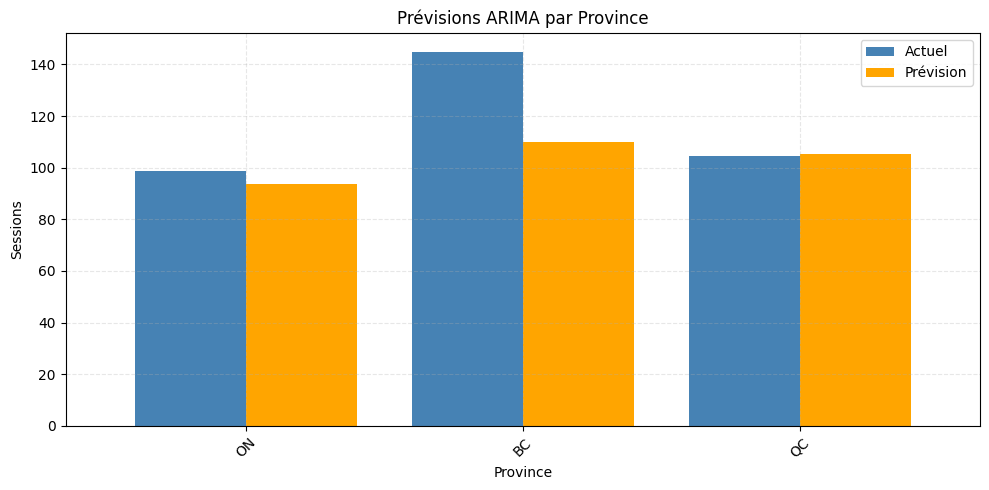

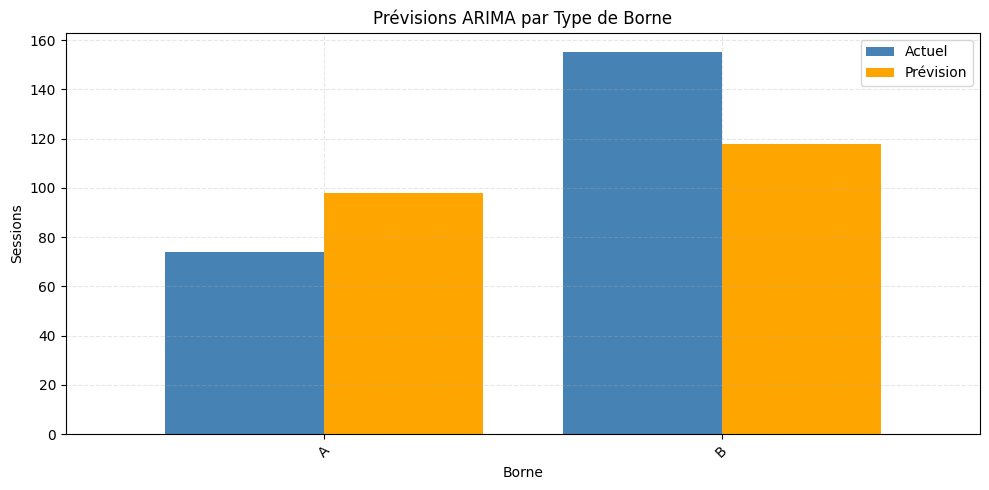

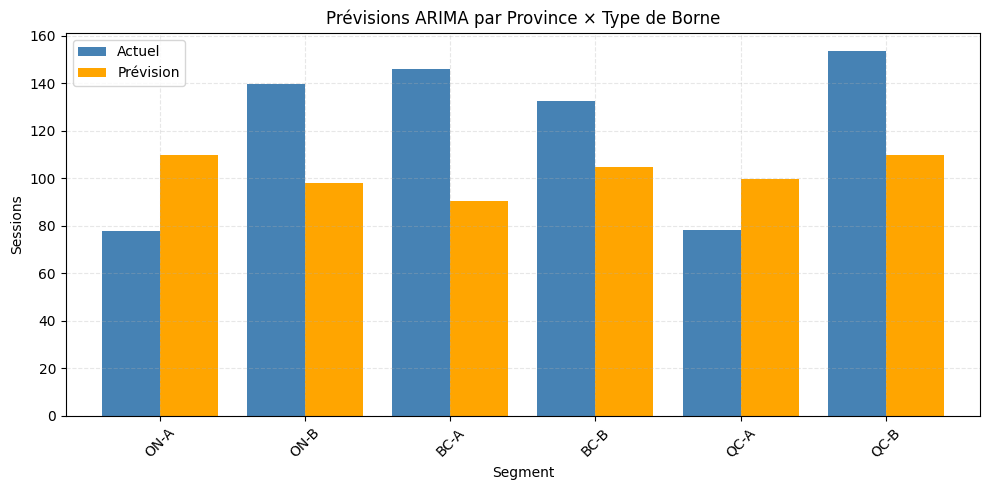

In [90]:


# =============================================================================
# 9. PREVISIONS PAR PROVINCE / BORNE AVEC ARIMA GLOBAL (VERSION SANS PRINT)
# =============================================================================

p_global, d_global, q_global = best_order   # paramètres trouvés plus tôt

df_grouped = df.reset_index()

# Dictionnaire pour stocker les prévisions
forecasts_dict = {}

# Fonction ARIMA
def apply_global_arima(series, p, d, q):
    try:
        model = ARIMA(series, order=(p, d, q))
        fitted = model.fit()
        forecast = fitted.forecast(steps=10)
        return fitted, forecast
    except:
        return None, None


# =============================================================================
# 9.1 PREVISIONS PAR PROVINCE
# =============================================================================
for province in df_grouped["province"].unique():
    df_prov = df_grouped[df_grouped["province"] == province].copy()
    df_prov = df_prov.set_index("date")
    series_prov = df_prov["sessions"].dropna()

    if len(series_prov) >= 15:
        model, forecast = apply_global_arima(series_prov, p_global, d_global, q_global)
        forecasts_dict[f"province_{province}"] = {
            "model": model,
            "forecast": forecast
        }


# =============================================================================
# 9.2 PREVISIONS PAR TYPE DE BORNE
# =============================================================================
for borne in df_grouped["borne_type"].unique():
    df_borne = df_grouped[df_grouped["borne_type"] == borne].copy()
    df_borne = df_borne.set_index("date")
    series_borne = df_borne["sessions"].dropna()

    if len(series_borne) >= 15:
        model, forecast = apply_global_arima(series_borne, p_global, d_global, q_global)
        forecasts_dict[f"borne_{borne}"] = {
            "model": model,
            "forecast": forecast
        }


# =============================================================================
# 9.3 PREVISIONS CROISEES (PROVINCE × BORNE)
# =============================================================================
for province in df_grouped["province"].unique():
    for borne in df_grouped["borne_type"].unique():
        df_cross = df_grouped[
            (df_grouped["province"] == province) &
            (df_grouped["borne_type"] == borne)
        ].copy()
        df_cross = df_cross.set_index("date")
        series_cross = df_cross["sessions"].dropna()

        if len(series_cross) >= 10:
            model, forecast = apply_global_arima(series_cross, p_global, d_global, q_global)
            forecasts_dict[f"{province}_{borne}"] = {
                "model": model,
                "forecast": forecast
            }


# =============================================================================
# CREATION DES TABLEAUX POUR LES GRAPHIQUES
# =============================================================================

# 1. Provinces
province_rows = []
for prov in df_grouped["province"].unique():
    key = f"province_{prov}"
    if key in forecasts_dict:
        current = (
            df_grouped[df_grouped["province"] == prov]["sessions"]
            .iloc[-5:]
            .mean()
        )
        forecast_mean = forecasts_dict[key]["forecast"].mean()
        province_rows.append([prov, current, forecast_mean])

df_province_plot = pd.DataFrame(province_rows, columns=["Province", "Actuel", "Prévision"])

# 2. Bornes
borne_rows = []
for borne in df_grouped["borne_type"].unique():
    key = f"borne_{borne}"
    if key in forecasts_dict:
        current = (
            df_grouped[df_grouped["borne_type"] == borne]["sessions"]
            .iloc[-5:]
            .mean()
        )
        forecast_mean = forecasts_dict[key]["forecast"].mean()
        borne_rows.append([borne, current, forecast_mean])

df_borne_plot = pd.DataFrame(borne_rows, columns=["Borne", "Actuel", "Prévision"])

# 3. Province × Borne
cross_rows = []
for prov in df_grouped["province"].unique():
    for borne in df_grouped["borne_type"].unique():
        key = f"{prov}_{borne}"
        if key in forecasts_dict:
            current = (
                df_grouped[
                    (df_grouped["province"] == prov) &
                    (df_grouped["borne_type"] == borne)
                ]["sessions"]
                .iloc[-5:]
                .mean()
            )
            forecast_mean = forecasts_dict[key]["forecast"].mean()
            cross_rows.append([f"{prov}-{borne}", current, forecast_mean])

df_cross_plot = pd.DataFrame(cross_rows, columns=["Segment", "Actuel", "Prévision"])


# =============================================================================
# GRAPHES LISIBLES (HISTOGRAMMES)
# =============================================================================

def plot_bar(df, title, x_col):
    if df.empty:
        return
    
    df_plot = df.set_index(x_col)
    
    df_plot.plot(
        kind="bar",
        figsize=(10, 5),
        color=["steelblue", "orange"],
        width=0.8
    )
    
    plt.title(title)
    plt.ylabel("Sessions")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Graphiques à afficher
plot_bar(df_province_plot, "Prévisions ARIMA par Province", "Province")
plot_bar(df_borne_plot, "Prévisions ARIMA par Type de Borne", "Borne")
plot_bar(df_cross_plot, "Prévisions ARIMA par Province × Type de Borne", "Segment")



12. HEATMAP DES PRÉVISIONS CROISÉES


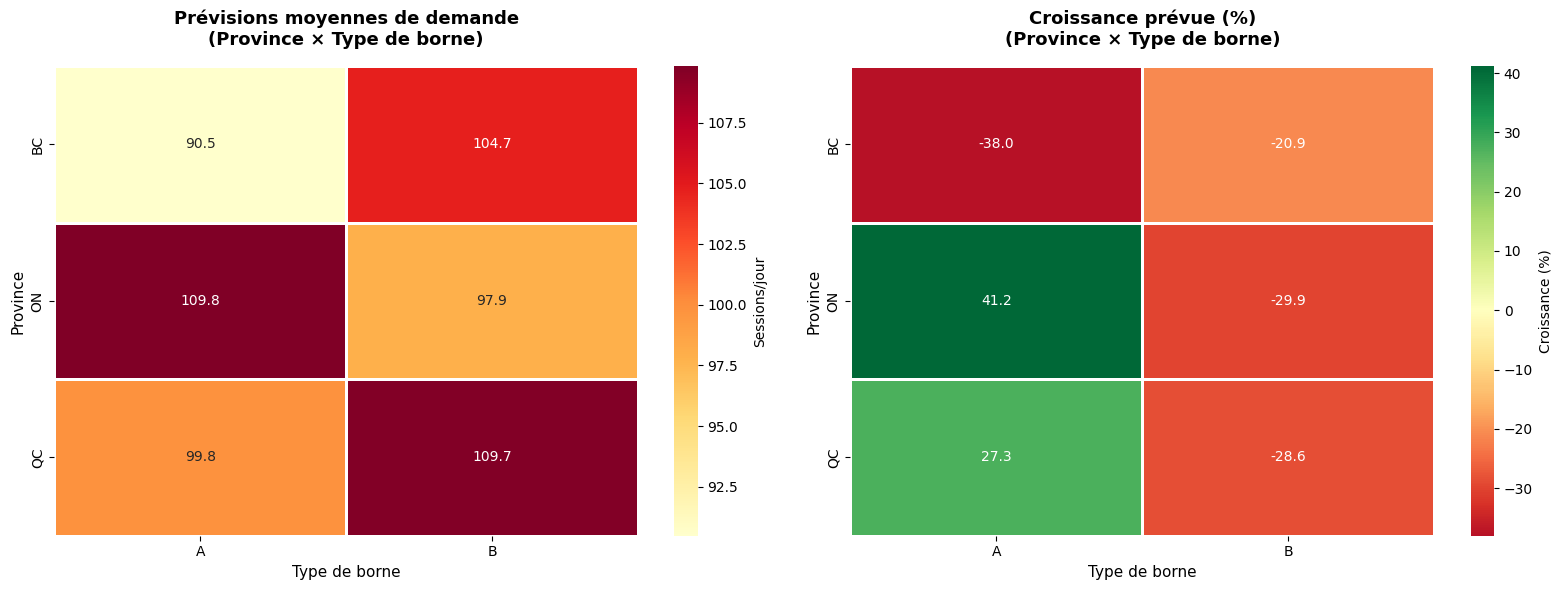

In [91]:
# =============================================================================
# 11. CONSTRUCTION DE df_forecast_summary
# =============================================================================

summary_rows = []

for prov in df_grouped["province"].unique():
    for borne in df_grouped["borne_type"].unique():
        
        key = f"{prov}_{borne}"
        if key not in forecasts_dict:
            continue
        
        forecast_mean = forecasts_dict[key]["forecast"].mean()
        current_mean = (
            df_grouped[
                (df_grouped["province"] == prov) &
                (df_grouped["borne_type"] == borne)
            ]["sessions"].iloc[-5:].mean()
        )
        
        growth = ((forecast_mean / current_mean) - 1) * 100
        
        summary_rows.append([
            prov,
            borne,
            current_mean,
            forecast_mean,
            growth
        ])

df_forecast_summary = pd.DataFrame(
    summary_rows,
    columns=["Province", "Type_Borne", "Actuel", "Prévision_moyenne", "Croissance_%"]
)

# 12. HEATMAP DES PRÉVISIONS CROISÉES

print("\n" + "=" * 80)
print("12. HEATMAP DES PRÉVISIONS CROISÉES")
print("=" * 80)

if len(df_forecast_summary) > 0:
    # Créer pivot table pour heatmap
    df_pivot = df_forecast_summary.pivot_table(
        index='Province', 
        columns='Type_Borne', 
        values='Prévision_moyenne', 
        aggfunc='mean'
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap 1: Prévisions moyennes
    sns.heatmap(df_pivot, annot=True, fmt='.1f', cmap='YlOrRd', 
                ax=axes[0], cbar_kws={'label': 'Sessions/jour'},
                linewidths=2, linecolor='white')
    axes[0].set_title('Prévisions moyennes de demande\n(Province × Type de borne)', 
                     fontsize=13, fontweight='bold', pad=15)
    axes[0].set_xlabel('Type de borne', fontsize=11)
    axes[0].set_ylabel('Province', fontsize=11)
    
    # Heatmap 2: Croissance prévue
    df_pivot_growth = df_forecast_summary.pivot_table(
        index='Province', 
        columns='Type_Borne', 
        values='Croissance_%', 
        aggfunc='mean'
    )
    
    sns.heatmap(df_pivot_growth, annot=True, fmt='.1f', cmap='RdYlGn', 
                ax=axes[1], cbar_kws={'label': 'Croissance (%)'},
                linewidths=2, linecolor='white', center=0)
    axes[1].set_title('Croissance prévue (%)\n(Province × Type de borne)', 
                     fontsize=13, fontweight='bold', pad=15)
    axes[1].set_xlabel('Type de borne', fontsize=11)
    axes[1].set_ylabel('Province', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('partie2_fig6_heatmap_forecasts.png', dpi=300, bbox_inches='tight')
   
    plt.show()



In [92]:
# =====================================================================
# RECONSTRUCTION COMPLÈTE DE forecasts_dict
# =====================================================================

new_forecasts = {}

for key, data in forecasts_dict.items():

    forecast = data.get("forecast", None)
    model = data.get("model", None)

    # sécuriser les forecast cassées
    if forecast is None or model is None:
        continue

    # détecter province ou borne
    if key.startswith("province_"):
        id_value = key.split("_")[1]
        current_mean = df[df["province"] == id_value]["sessions"].iloc[-5:].mean()

    elif key.startswith("borne_"):
        id_value = key.split("_")[1]
        current_mean = df[df["borne_type"] == id_value]["sessions"].iloc[-5:].mean()

    else:
        # Cas province × borne
        prov, borne = key.split("_")
        id_value = f"{prov}_{borne}"
        current_mean = df[(df["province"] == prov) & 
                          (df["borne_type"] == borne)]["sessions"].iloc[-5:].mean()

    # Écriture propre
    new_forecasts[key] = {
        "model": model,
        "forecast": forecast,
        "order": best_order,             # ✔ tu ajoutes l’ordre
        "current_mean": current_mean     # ✔ tu ajoutes la moyenne actuelle
    }

# remplacer l'ancien dictionnaire
forecasts_dict = new_forecasts
print("✔ forecasts_dict reconstruit avec succès.")


✔ forecasts_dict reconstruit avec succès.



11. VISUALISATIONS DES PRÉVISIONS CROISÉES

 Graphique sauvegardé: partie2_fig5_forecasts_croises.png


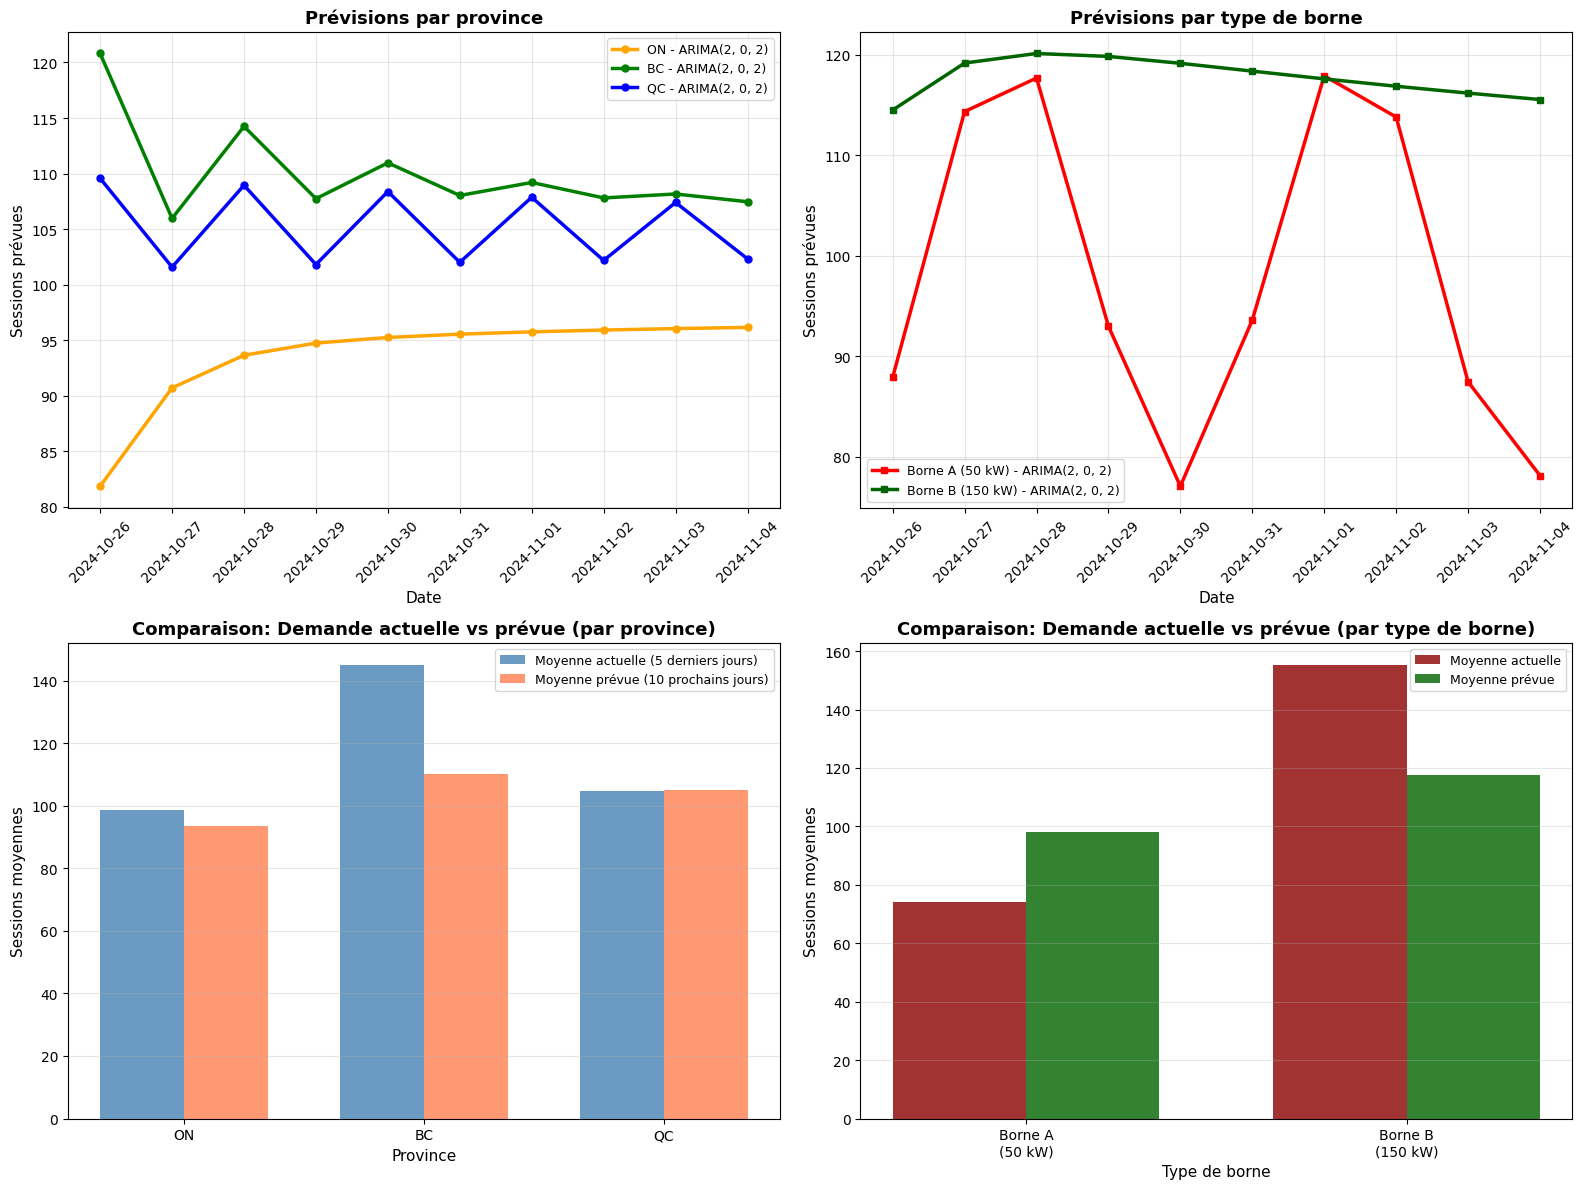

In [93]:
# =============================================================================
# 11. VISUALISATIONS DES PRÉVISIONS CROISÉES
# =============================================================================

print("\n" + "=" * 80)
print("11. VISUALISATIONS DES PRÉVISIONS CROISÉES")
print("=" * 80)

# 11.1 Graphique comparatif par province
if len(forecasts_dict) > 0:
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Graphique 1: Prévisions par province
    ax = axes[0, 0]
    colors_prov = {'QC': 'blue', 'ON': 'orange', 'BC': 'green'}
    
    for key, data in forecasts_dict.items():
        if key.startswith('province_'):
            province = key.split('_')[1]
            forecast_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), 
                                          periods=len(data['forecast']), freq='D')
            ax.plot(forecast_dates, data['forecast'], 
                   label=f"{province} - ARIMA{data['order']}", 
                   linewidth=2.5, marker='o', markersize=5, 
                   color=colors_prov.get(province, 'gray'))
    
    ax.set_title('Prévisions par province', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Sessions prévues', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    # Graphique 2: Prévisions par type de borne
    ax = axes[0, 1]
    colors_borne = {'A': 'red', 'B': 'darkgreen'}
    
    for key, data in forecasts_dict.items():
        if key.startswith('borne_'):
            borne = key.split('_')[1]
            borne_label = f"Borne {borne} ({'50 kW' if borne == 'A' else '150 kW'})"
            forecast_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), 
                                          periods=len(data['forecast']), freq='D')
            ax.plot(forecast_dates, data['forecast'], 
                   label=f"{borne_label} - ARIMA{data['order']}", 
                   linewidth=2.5, marker='s', markersize=5, 
                   color=colors_borne.get(borne, 'gray'))
    
    ax.set_title('Prévisions par type de borne', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Sessions prévues', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    
    # Graphique 3: Comparaison sessions actuelles vs prévues (par province)
    ax = axes[1, 0]
    
    prov_data = []
    for key, data in forecasts_dict.items():
        if key.startswith('province_'):
            province = key.split('_')[1]
            prov_data.append({
                'Province': province,
                'Actuel': data['current_mean'],
                'Prévu': data['forecast'].mean()
            })
    
    if len(prov_data) > 0:
        df_prov_comp = pd.DataFrame(prov_data)
        x_pos = np.arange(len(df_prov_comp))
        width = 0.35
        
        ax.bar(x_pos - width/2, df_prov_comp['Actuel'], width, 
               label='Moyenne actuelle (5 derniers jours)', color='steelblue', alpha=0.8)
        ax.bar(x_pos + width/2, df_prov_comp['Prévu'], width, 
               label='Moyenne prévue (10 prochains jours)', color='coral', alpha=0.8)
        
        ax.set_title('Comparaison: Demande actuelle vs prévue (par province)', 
                    fontsize=13, fontweight='bold')
        ax.set_xlabel('Province', fontsize=11)
        ax.set_ylabel('Sessions moyennes', fontsize=11)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(df_prov_comp['Province'])
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    
    # Graphique 4: Comparaison par type de borne
    ax = axes[1, 1]
    
    borne_data = []
    for key, data in forecasts_dict.items():
        if key.startswith('borne_'):
            borne = key.split('_')[1]
            borne_data.append({
                'Type': f"Borne {borne}\n({'50 kW' if borne == 'A' else '150 kW'})",
                'Actuel': data['current_mean'],
                'Prévu': data['forecast'].mean()
            })
    
    if len(borne_data) > 0:
        df_borne_comp = pd.DataFrame(borne_data)
        x_pos = np.arange(len(df_borne_comp))
        width = 0.35
        
        ax.bar(x_pos - width/2, df_borne_comp['Actuel'], width, 
               label='Moyenne actuelle', color='darkred', alpha=0.8)
        ax.bar(x_pos + width/2, df_borne_comp['Prévu'], width, 
               label='Moyenne prévue', color='darkgreen', alpha=0.8)
        
        ax.set_title('Comparaison: Demande actuelle vs prévue (par type de borne)', 
                    fontsize=13, fontweight='bold')
        ax.set_xlabel('Type de borne', fontsize=11)
        ax.set_ylabel('Sessions moyennes', fontsize=11)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(df_borne_comp['Type'])
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('partie2_fig5_forecasts_croises.png', dpi=300, bbox_inches='tight')
    print("\n Graphique sauvegardé: partie2_fig5_forecasts_croises.png")
    plt.show()


In [95]:
# =============================================================================
# 14. CONCLUSIONS ET RECOMMANDATIONS STRATÉGIQUES
# =============================================================================

print("\n" + "=" * 80)
print("14. CONCLUSIONS ET RECOMMANDATIONS STRATÉGIQUES")
print("=" * 80)
model_global = ARIMA(df["sessions"], order=best_order).fit()
forecast_global = model_global.forecast(10)

# Calcul tendance générale
first_week = df['sessions'].iloc[:7].mean()
last_week = df['sessions'].iloc[-7:].mean()
trend_pct = ((last_week / first_week) - 1) * 100

# Corrélation température si disponible
corr_temp = df['sessions'].corr(df['temperature']) if "temperature" in df.columns else None

print(f"""
╔═══════════════════════════════════════════════════════════════════════════╗
║                    SYNTHÈSE DE L'ANALYSE STOCHASTIQUE                     ║
╚═══════════════════════════════════════════════════════════════════════════╝

 MODÈLE GLOBAL RETENU:
   • ARIMA{best_order}
   • Prévision moyenne à 10 jours : {forecast_global.mean():.2f} sessions/jour
   • Tendance : {'Croissance' if forecast_global.iloc[-1] > forecast_global.iloc[0] else 'Décroissance'}

 TENDANCES OBSERVÉES:
   • Demande première semaine : {first_week:.2f} sessions/jour
   • Demande dernière semaine : {last_week:.2f} sessions/jour
   • Évolution totale : {trend_pct:+.2f}%
""")

if corr_temp is not None:
    print(f"   • Corrélation Sessions ↔ Température : r = {corr_temp:.3f}")

print("""
 RECOMMANDATIONS PAR SEGMENT:
""")

# Construction d’un tableau résumé prévisions (propre)
summary_rows = []
for key, data in forecasts_dict.items():
    name = key
    previs = data["forecast"].mean()
    current = data["current_mean"]
    summary_rows.append([name, current, previs])

df_summary = pd.DataFrame(summary_rows, columns=["Segment", "Actuel", "Prévision_moyenne"])

# Séparer province / borne si possible
if len(df_summary) > 0:
    print("    PRIORISATION GÉOGRAPHIQUE:")
    prov = df_summary[df_summary["Segment"].str.startswith("province_")]
    prov["Province"] = prov["Segment"].str.replace("province_", "")
    prov = prov.groupby("Province")["Prévision_moyenne"].mean().sort_values(ascending=False)
    for i, (p, val) in enumerate(prov.items(), 1):
        print(f"      {i}. {p} : {val:.2f} sessions/jour prévues")

    print("\n    PRIORISATION PAR TYPE DE BORNE:")
    brn = df_summary[df_summary["Segment"].str.startswith("borne_")]
    brn["Borne"] = brn["Segment"].str.replace("borne_", "")
    brn = brn.groupby("Borne")["Prévision_moyenne"].mean().sort_values(ascending=False)
    for i, (b, val) in enumerate(brn.items(), 1):
        label = "50 kW" if b == "A" else "150 kW"
        print(f"      {i}. Borne {b} ({label}) : {val:.2f} sessions/jour")

print(f"""
 ACTIONS STRATÉGIQUES RECOMMANDÉES:

    COURT TERME (0-3 mois):
      • Augmenter la capacité dans les segments à forte croissance
      • Renforcer la maintenance préventive des bornes les plus sollicitées
      • Surveiller les températures extrêmes qui augmentent les durées de recharge

    MOYEN TERME (3-12 mois):
      • Déployer prioritairement des bornes rapides (150 kW) dans les zones à forte demande
      • Optimiser la répartition géographique selon les prévisions ARIMA
      • Installer un monitoring de performance en temps réel

    LONG TERME (12+ mois):
      • Planifier l'expansion du réseau basée sur les tendances prévisionnelles
      • Renforcer l’alimentation électrique des sites critiques
      • Développer un modèle prédictif en temps réel pour ajustement dynamique

╔═══════════════════════════════════════════════════════════════════════════╗
║                          FIN DE L'ANALYSE PARTIE 2                        ║
╚═══════════════════════════════════════════════════════════════════════════╝
""")



14. CONCLUSIONS ET RECOMMANDATIONS STRATÉGIQUES

╔═══════════════════════════════════════════════════════════════════════════╗
║                    SYNTHÈSE DE L'ANALYSE STOCHASTIQUE                     ║
╚═══════════════════════════════════════════════════════════════════════════╝

 MODÈLE GLOBAL RETENU:
   • ARIMA(2, 0, 2)
   • Prévision moyenne à 10 jours : 99.50 sessions/jour
   • Tendance : Croissance

 TENDANCES OBSERVÉES:
   • Demande première semaine : 118.57 sessions/jour
   • Demande dernière semaine : 114.43 sessions/jour
   • Évolution totale : -3.49%

   • Corrélation Sessions ↔ Température : r = 0.009

 RECOMMANDATIONS PAR SEGMENT:

    PRIORISATION GÉOGRAPHIQUE:
      1. BC : 110.04 sessions/jour prévues
      2. QC : 105.21 sessions/jour prévues
      3. ON : 93.57 sessions/jour prévues

    PRIORISATION PAR TYPE DE BORNE:
      1. Borne B (150 kW) : 117.71 sessions/jour
      2. Borne A (50 kW) : 98.09 sessions/jour

 ACTIONS STRATÉGIQUES RECOMMANDÉES:

    COURT TERM